# **Wykorzystanie sztucznej inteligencji do analizy naruszeń praw człowieka na podstawie wskaźników społeczno-ekonomicznych**

---

Celem pracy dyplomowej jest zaprojektowanie, implementacja oraz ocena modelu uczenia maszynowego do prognozowania poziomu przestrzegania praw człowieka w państwach członkowskich Organizacji Narodów Zjednoczonych w latach 2025–2100.

W analizie wykorzystano dziewięć wskaźników rozwoju społeczno-ekonomicznego pełniących funkcję zmiennych objaśniających oraz miarę poziomu przestrzegania praw człowieka jako zmienną objaśnianą, określoną na podstawie wskaźnika Freedom in the World. W dalszej części pracy, dla uproszczenia nazewnictwa, zmienna ta będzie określana wskaźnikiem wolności.

### **Część 1 → Przygotowanie danych (analiza braków oraz stworzenie finalnych zbiorów)**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import seaborn as sns

# 1. Charakterystyka wskaźników oraz metody imputacji brakujących wartości

### Wskaźnik wolności (Freedom in the World)

https://freedomhouse.org/report/freedom-world#Data

Jako miarę stanu praw człowieka przyjęto wskaźnik Freedom in the World publikowany przez organizację Freedom House. Składa się on z dwóch komponentów: praw politycznych (PR) oraz wolności obywatelskich (CL), ocenianych w skali od 1 do 7, gdzie niższa wartość oznacza wyższy poziom wolności.

Zbiór danych obejmuje roczne oceny dla krajów i terytoriów w latach 1973–2024.

Choć wskaźnik nie zlicza pojedynczych incydentów naruszeń praw człowieka, syntetyzuje ogólny stan ochrony jednostki przed represjami państwowymi, co może pozwolić wykrywać zależności między sytuacją społeczno-ekonomiczną a poziomem
tej ochrony.

In [2]:
df = pd.read_excel("fiw.xlsx", sheet_name="Country Ratings, Statuses ", header=[1, 2], na_values="-")
df = df.drop('Status', axis=1, level=1)
df = df.rename(columns={"CL ": "CL"}, level=1)
df = df.set_index(('Year(s) Under Review', 'Unnamed: 0_level_1'))
df.index.name = 'country'

df.columns = [f"{i}_{j}" if j != '' else f"{i}" for i, j in df.columns]
df = df.copy()
df.reset_index(inplace=True)

df = df.melt(id_vars='country', var_name='Year_Indicator', value_name='Value')
df[['year', 'Indicator']] = df['Year_Indicator'].str.split('_', expand=True)
df.drop(columns='Year_Indicator', inplace=True)
df = df[df['year'].apply(lambda x: str(x).isdigit() and int(x) >= 1990)]

df = df.pivot(
    index=['country', 'year'],
    columns='Indicator',
    values='Value'
).reset_index()

df.columns.name = None
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['PR'] = pd.to_numeric(df['PR'], errors='coerce')
df['CL'] = pd.to_numeric(df['CL'], errors='coerce')
df['country'] = df['country'].astype('string')
df

,country,year,CL,PR
0,Afghanistan,1990,7.0,7.0
1,Afghanistan,1991,7.0,7.0
2,Afghanistan,1992,6.0,6.0
3,Afghanistan,1993,7.0,7.0
4,Afghanistan,1994,7.0,7.0
...,...,...,...,...
7170,Zimbabwe,2020,5.0,6.0
7171,Zimbabwe,2021,5.0,6.0
7172,Zimbabwe,2022,5.0,6.0
7173,Zimbabwe,2023,5.0,6.0


***Założenie*** <br>
Ograniczenie analizy do krajów ONZ wynika z konieczności zapewnienia spójności i wysokiej jakości danych statystycznych. Wykluczenie terytoriów o nieuregulowanym statusie pozwala uniknąć luk informacyjnych, co bezpośrednio przekłada się na stabilność procesu uczenia oraz wiarygodność predykcji.

In [3]:
country = pd.read_csv("un_member.csv", sep=";", index_col=0, keep_default_na=False)
country.sort_index(inplace=True)
country_map = country.copy()

In [4]:
df['country'] = df['country'].str.replace(r"[,\.\s]", "", regex=True).str.lower()
yugoslavia = df[df['country'].isin(['yugoslavia', 'serbiaandmontenegro'])].copy()
country_map.index = country_map.index.str.replace(r"[,\.\s]", "", regex=True).str.lower()

In [5]:
print("\nKraje nienależące do ONZ:", set(df['country']) - set(country_map.index))
print("\nKraje ONZ których brakuje w tabeli:", set(country_map.index) - set(df['country']))


Kraje nienależące do ONZ: {'taiwan', 'yemens', 'kosovo', 'germanye', 'yugoslavia', 'serbiaandmontenegro', 'germanyw', 'vietnams', 'vietnamn', 'czechoslovakia', 'yemenn', 'ussr'}

Kraje ONZ których brakuje w tabeli: set()


Do tabeli zostały dodane kolumny z kodami ISO3, ISO2 oraz znormalizowanymi nazwami krajów.

In [6]:
df = df.loc[df['country'].isin(country_map.index)].copy()
df['country_normalized'] = df['country']
df['country_code'] = df['country_normalized'].map(dict(zip(country_map.index, country_map['iso3'])))
df['country_name'] = df['country_code'].map(dict(zip(country['iso3'], country.index)))
df['iso2'] = df['country_code'].map(dict(zip(country['iso3'], country['iso2'])))
df.index.isna().any()

np.False_

#### Braki danych
Analiza braków została sporządzona na podstawie kolumny CL (Civil Liberties), ponieważ wykazuje ona taką samą liczbę braków jak PR (Political Rights).

In [7]:
(df['CL'].isna() == df['PR'].isna()).all()

np.True_

In [8]:
missing = df.groupby('year')['CL'].apply(lambda x: x.isna().sum())
missing = missing.to_frame(name='Liczba braków')
missing = missing.loc[missing.index <= 2012]
missing

,Liczba braków
year,
1990,33
1991,14
1992,10
1993,5
1994,4
1995,4
1996,4
1997,4
1998,4


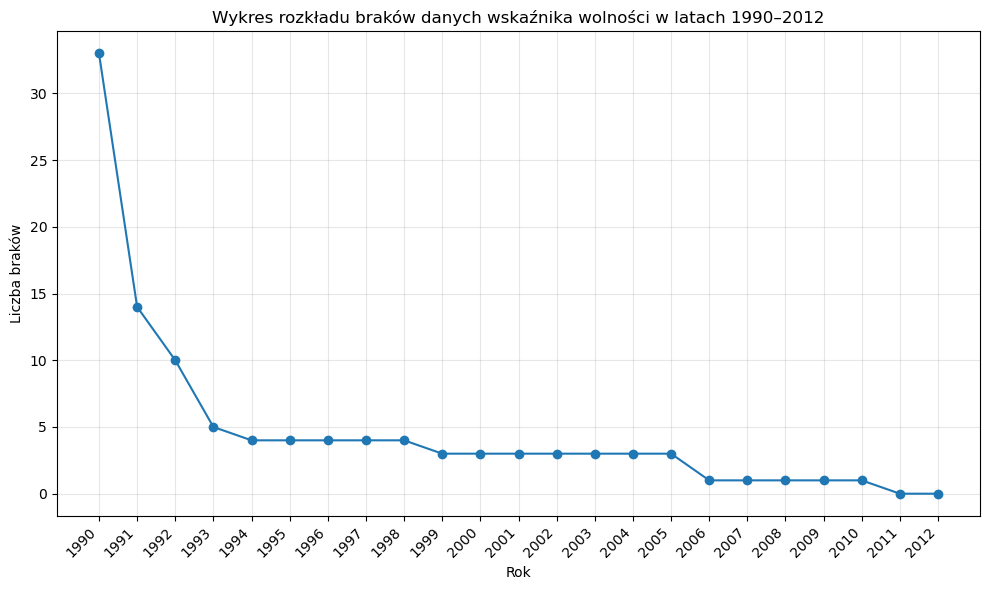

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    missing.index,
    missing['Liczba braków'],
    marker='o'
)

ax.set_ylabel('Liczba braków')
ax.set_xlabel('Rok')
ax.set_title("Wykres rozkładu braków danych wskaźnika wolności w latach 1990–2012")
ax.grid(True, alpha=0.3)

ax.set_xticks(missing.index)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Liczba braków danych, która w 1990 roku wynosiła 33, spadła do 5 w roku 1993.

Sytuacja ta wiąże się z procesem formowania się nowych państw na początku lat 90. XX wieku. Z punktu widzenia prognozowania szeregów czasowych, ograniczenie zbioru wyłącznie do okresu pełnej dostępności danych (2011–2024) byłoby nieuzasadnione, gdyż wiązałoby się z utratą istotnych informacji historycznych.

W związku z powyższym, jako punkt początkowy dalszej analizy przyjęto rok 1993. Wybór ten stanowi optymalny kompromis pomiędzy dążeniem do maksymalizacji długości szeregu czasowego a koniecznością zapewnienia wysokiej jakości danych wejściowych.

In [10]:
df = df[df['year'] >= 1993]
df_withoutna = df.dropna()

missing_countries = df.loc[df['CL'].isna(), 'country_name'].unique()

allYears = set(range(1993, 2025))
missing = {}

for country in missing_countries:
    available_years = set(
        df_withoutna.loc[df_withoutna['country_name'] == country, 'year']
    )
    missing[country] = sorted(allYears - available_years)

missing

{'East Timor': [1993, 1994, 1995, 1996, 1997, 1998],
 'Montenegro': [1993,
  1994,
  1995,
  1996,
  1997,
  1998,
  1999,
  2000,
  2001,
  2002,
  2003,
  2004,
  2005],
 'Palau': [1993],
 'Serbia': [1993,
  1994,
  1995,
  1996,
  1997,
  1998,
  1999,
  2000,
  2001,
  2002,
  2003,
  2004,
  2005],
 'South Sudan': [1993,
  1994,
  1995,
  1996,
  1997,
  1998,
  1999,
  2000,
  2001,
  2002,
  2003,
  2004,
  2005,
  2006,
  2007,
  2008,
  2009,
  2010]}

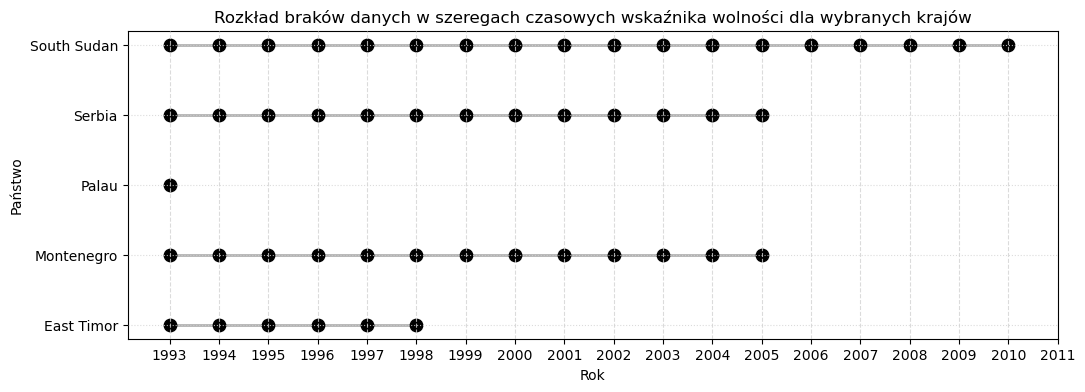

In [11]:
fig, ax = plt.subplots(figsize=(12,4))
ax.set_facecolor('white')

for country, years in missing.items():
    if len(years) > 1:
        ax.plot(
            [min(years), max(years)],
            [country, country],
            linewidth=2,
            alpha=0.3,
            zorder=1,
            color = 'black'
        )

    ax.scatter(
        years,
        [country] * len(years),
        s=80,
        zorder=2,
        color = 'black'
    )

ax.set_xlabel('Rok')
ax.set_ylabel('Państwo')
ax.set_title('Rozkład braków danych w szeregach czasowych wskaźnika wolności dla wybranych krajów')

ax.set_xticks(range(1993, 2012))

ax.set_axisbelow(False)
ax.grid(True, axis='x', linestyle='--', color='lightgray', alpha=0.8)
ax.grid(True, axis='y', linestyle=':',  color='lightgray', alpha=0.8)

plt.show()


Luki w danych dla wybranych państw wynikają z ich ewolucji geopolitycznej w badanym okresie (1993–2024). W celu zachowania ciągłości szeregów czasowych przyjęto następujące zasady uzupełniania danych:
- **Serbia oraz Czarnogóra** <br>
W latach 1992–2003 oba kraje tworzyły Federalną Republikę Jugosławii, a następnie (2003–2006) funkcjonowały jako wspólnota państwowa Serbii i Czarnogóry. Brakujące wartości dla obu podmiotów sprzed 2006 roku zostaną uzupełnione danymi przypisanymi ich historycznym poprzednikom, które figurują w zestawieniu zbiorczym.

 - **Timor Wschodni** <br>
Mimo to, że państwo uzyskało pełną suwerenność w 2002 roku, w zestawieniu zbiorczym występuje jako niepodległy podmiot od 1999 roku (referendum niepodległościowe). W latach 1993–1998 organizacja Freedom House klasyfikowała ten obszar jako terytorium sporne pod administracją Indonezji. Brakujące wartości zostały pozyskane drogą kwerendy oryginalnych raportów rocznych i ręcznie przypisane do bazy danych.

- **Palau** <br>
Kraj uzyskał niepodległość w 1994 roku, a wcześniej figurował w raportach Freedom House jako terytorium powiernicze pod administracją USA. Dane za rok 1993 zostały uzupełnione na podstawie archiwalnego raportu z tamtego okresu [26].

- **Sudan Południowy** <br>
Państwo to powstało w 2011 roku wskutek secesji od Sudanu. Przed tą datą terytorium dzisiejszego Sudanu Południowego nie było uregulowane, stąd brak jakichkolwiek danych. Przyjęto założenie metodologiczne, że luki w danych za lata 1993–2010 zostaną uzupełnione wskaźnikami Sudanu sprzed podziału. Metoda ta pozwala najlepiej odzwierciedlić ogólne warunki polityczno-społeczne panujące na tym obszarze przed uzyskaniem niepodległości.

In [12]:
yugoslavia1 = yugoslavia[((yugoslavia['year'].isin(range(1993, 2003))) & (yugoslavia['country'] == 'yugoslavia')) |
                        ((yugoslavia['year'].isin(range(2003, 2006))) & (yugoslavia['country'] == 'serbiaandmontenegro'))].copy()
yugoslavia1.sort_values(by=['year'], inplace=True)
yugoslavia1.reset_index(drop=True, inplace=True)

serbia = yugoslavia1.copy()
serbia['country'] = 'serbia'
montenegro = yugoslavia1.copy()
montenegro['country'] = 'montenegro'

sudan = df[(df['country'] == 'sudan') & (df['year'].isin(range(1993, 2011)))][['country', 'year', 'CL', 'PR']].copy()
sudan['country'] = 'southsudan'

timor = pd.DataFrame({
    'country': ['easttimor'] * 6,
    'year': list(range(1993, 1999)),
    'CL': [7, 7, 7, 7, 7, 6],
    'PR': [7, 7, 7, 7, 7, 7]
})

palau = pd.DataFrame({
    'country': ['palau'],
    'year': [1993],
    'CL': [2],
    'PR': [1]
})

In [13]:
def merge_data(countries_data, data):
    for country in countries_data:
        data = data.merge(country, on=['country', 'year'], how='left', suffixes=('', '_2'))
        data['CL'] = data['CL'].fillna(data['CL_2'])
        data['PR'] = data['PR'].fillna(data['PR_2'])
        data.drop(columns=['CL_2', 'PR_2'], inplace=True)

    return data

df = merge_data([serbia, montenegro, sudan, timor, palau], df)

Wskaźnik wolności składa się z dwóch komponentów, ocenianych w skali od 1 do 7, przy czym wartość 1 oznacza najwyższy poziom wolności, a 7 – najniższy. Taka konstrukcja skali jest nieintuicyjna w kontekście korelacji ze wskaźnikami ekonomicznymi, gdzie zazwyczaj wyższe wartości reprezentują korzystniejsze zjawiska. W celu ujednolicenia kierunku interpretacji zmiennych dokonano inwersji skali obu komponentów. W wyniku tej transformacji wartość 7 odpowiada maksymalnemu poziomowi wolności, a 1 minimalnemu. Następnie, aby zredukować wymiarowość danych przy jednoczesnym zachowaniu informacji o ogólnym stanie przestrzegania praw człowieka w danym państwie, oba komponenty zintegrowano w jeden zbiorczy wskaźnik wolności, wyznaczony jako średnia arytmetyczna.

In [14]:
df['PR'] = 8 - df['PR']
df['CL'] = 8 - df['CL']
df['freedom_score'] = df[['PR', 'CL']].mean(axis=1)
fiw = df[['country_normalized', 'year', 'freedom_score']]
fiw.reset_index(drop=True, inplace=True)

**Założenie** <br>
Ze względu na odległy horyzont czasowy, w badaniu wykorzystano scenariusze Wspólnych Ścieżek Społeczno-Ekonomicznych (ang. Shared Socioeconomic Pathways – SSP). To pięć narracji opisujących alternatywne kierunki globalnego rozwoju, które mają na celu dostarczenie spójnych ram do modelowania wpływu zmian klimatycznych, przemian demograficznych i gospodarczych na społeczeństwa. Ich szczegółową charakterystykę przedstawił zespół naukowców pod przewodnictwem Briana O’Neilla, we współpracy z Międzyrządowym Panelem ds. Zmian Klimatu (IPCC). W pracy modelowanie ograniczono do trzech scenariuszy, które wyznaczają logiczny zakres przewidywań (od progresu, przez stagnację, po regres).

1. **Scenariusz SSP1 (Zrównoważony rozwój)** <br>
Wariant optymistyczny,zakładający szybki wzrost poziomu edukacji,spadek nierówności i silną współpracę międzynarodową.

2. **Scenariusz SSP2 (Kontynuacja trendów)** <br>
Scenariusz bazowy, będący kontynuacją historycznych trendów rozwoju, gdzie postęp
społeczny i polityczny następuje w dotychczasowym, umiarkowanym tempie.

3. **Scenariusz SSP3 (Rywalizacja regionalna)** <br>
Wariant pesymistyczny, zakładający globalną fragmentację i priorytetyzację interesów
narodowych, w którym rywalizacja o zasoby wypiera współpracę międzynarodową.

Rezygnacja z pozostałych ścieżek (SSP4 i SSP5) podyktowana jest dbałością o klarowność modelu i unikanie redundancji. SSP4, opisujący specyficzne rozwarstwienie społeczne, mieści się w przedziale wartości wyznaczonym przez SSP2 i SSP3, nie wnosząc nowej charakterystyki skrajnej. Z kolei SSP5, choć opiera się na innym modelu energetycznym niż SSP1, pod względem potencjału społecznego i poziomu dobrobytu powiela jego wzorce.

Przyjęta selekcja państw i scenariuszy tworzy spójne ramy badawcze. Pozwala to na precyzyjne wyznaczenie trajektorii zmian w obszarze praw człowieka, opierając prognozy na mierzalnych parametrach rozwoju cywilizacyjnego.

Jednak nie wszystkie wskaźniki wykorzystywane w analizie posiadają pełne projekcje w ramach ścieżek SSP. W przypadku danych demograficznych wykorzystano warianty opracowane przez ONZ, który stosuje warianty płodności, które można powiązać z odpowiednimi ścieżkami SSP w następujący sposób:

1. **Niska Płodność → SSP1** <br>
Wariant zakłada, że współczynnik dzietności ogólnej pozostaje o 0.5 urodzenia poniżej wariantu średniego. Odpowiada logice SSP1, która przewiduje wysokie inwestycje w edukację i ochronę zdrowia oraz szybszą emancypację kobiet.

2. **Średnia Płodność → SSP2** <br>
Wariant średni stanowi medianę tysięcy trajektorii probabilistycznych. Odpowiada on scenariuszowi SSP2, który zakłada kontynuację dotychczasowych trendów rozwojowych.

3. **Wysoka Płodność → SSP3** <br>
Wariant ten zakłada dzietność o 0.5 urodzenia wyższą niż w scenariuszu średnim. Dopasowanie do SSP3 wynika z założenia, że przy słabym wzroście gospodarczym i niskich nakładach na edukację dzietność utrzyma się na wyższym poziomie.

Należy podkreślić, że wskaźnik śmiertelności niemowląt oraz saldo migracji nie posiadają odrębnych projekcji scenariuszowych. Dla nich ONZ stosuje jednolite założenia prognostyczne, niezależne od wariantów płodności. Zbieżność tych zmiennych pomiędzy scenariuszami wynika więc z metodologii ONZ, a nie z ich rzeczywistej niewrażliwości na czynniki społeczno-ekonomiczne. Pomimo tego, zmienne zostały zachowane w modelu predykcyjnym ze względu na wysoką wartość informacyjną. Pełnią funkcję predyktorów kontrolnych, które różnicują kraje i lata w ramach danego scenariusza SSP, natomiast nie determinują różnic między scenariuszami. Takie podejście pozwala zachować spójność metodologiczną przy jednoczesnym wykorzystaniu pełnej informacji zawartej w tych wskaźnikach.


In [15]:
def analyze_completeness(**datasets: pd.DataFrame) -> pd.DataFrame:
    for name, df in datasets.items():
        missing_countries = set(country_map.index) - set(df['country_normalized'])
        if missing_countries:
            print(f"W zbiorze '{name}' brakuje krajów ONZ: {missing_countries}")
        else:
            print(f"W zbiorze '{name}' są wszystkie kraje ONZ.")

    all_countries = set()
    all_years = set()
    for df in datasets.values():
        all_countries.update(df['country_normalized'].unique())
        all_years.update(df['year'].unique())

    expected_records = 193 * len(all_years)

    completeness = []
    for name, df in datasets.items():
        existing = len(df)
        completeness.append({
            'Dataset': name,
            'Liczba krajów': df['country_normalized'].nunique(),
            'Liczba lat': df['year'].nunique(),
            'Zakres': f"{int(df['year'].min())}-{int(df['year'].max())}",
            'Obecne rekordy': existing,
            'Brakujące rekordy': expected_records - existing,
            'Kompletność (%)': round(existing / expected_records * 100, 2)
        })

    completeness_df = pd.DataFrame(completeness)
    print("\nANALIZA KOMPLETNOŚCI:")
    print(f"Oczekiwana liczba rekordów (kraje * lata): {expected_records}")
    return completeness_df

In [16]:
def analyze_missing(**datasets: pd.DataFrame) -> pd.DataFrame:
    all_countries = set()
    all_years = set()
    for df in datasets.values():
        all_countries.update(df['country_normalized'].unique())
        all_years.update(df['year'].unique())

    missing_summary_list = []

    for name, df in datasets.items():
        existing = set(zip(df['country_normalized'], df['year']))
        all_combinations = set((country, year) for country in all_countries for year in all_years)
        missing = all_combinations - existing

        if missing:
            missing_by_country = {}
            for country, year in missing:
                if country not in missing_by_country:
                    missing_by_country[country] = []
                missing_by_country[country].append(year)

            for country, years in missing_by_country.items():
                years_sorted = sorted(years)
                ranges = []
                start = prev = years_sorted[0]
                for year in years_sorted[1:]:
                    if year == prev + 1:
                        prev = year
                    else:
                        ranges.append(f"{start}-{prev}" if start != prev else f"{start}")
                        start = prev = year
                ranges.append(f"{start}-{prev}" if start != prev else f"{start}")
                readable_years = ", ".join(ranges)

                missing_summary_list.append({
                    'Dataset': name,
                    'Kraj': country,
                    'Brakujące lata': readable_years
                })

    missing_summary_df = pd.DataFrame(missing_summary_list)
    print("BRAKUJĄCE DANE:")
    return missing_summary_df

---

### 1. Gęstość zaludnienia

https://population.un.org/dataportal/

_Historyczne 1950 - 2023, Projekcje 2024-2100_

Opisuje liczbę ludności przypadającą na jednostkę powierzchni. Zmienna ta pełni funkcję kontekstową, umożliwiając różnicowanie państw o zbliżonym poziomie rozwoju, lecz odmiennej strukturze przestrzennej. Wpływa pośrednio na dostępność usług publicznych, kontrolę społeczną oraz efektywność zarządzania państwem.

In [17]:
p_density1 = pd.read_csv("unpopulation_population_density.csv", usecols=['Iso3', 'Time', 'Variant', 'Value'])
p_density1.columns = ['country_normalized', 'year', 'scenario', 'p_density']
p_density1['country_normalized'] = p_density1['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
p_density1 = p_density1[p_density1['year'] >= 1993].reset_index(drop=True)
p_density1.dropna(inplace=True)

p_density3 = pd.concat([
    p_density1[(p_density1['scenario'] == 'Median') & (p_density1['year'] <= 2023)],
    p_density1[(p_density1['scenario'] == 'High-fertility') & (p_density1['year'] >= 2024)]
])[['country_normalized', 'year', 'p_density']]

p_density2 = p_density1[(p_density1['scenario'] == 'Median')][['country_normalized', 'year', 'p_density']]

p_density1 = pd.concat([
    p_density1[(p_density1['scenario'] == 'Median') & (p_density1['year'] <= 2023)],
    p_density1[(p_density1['scenario'] == 'Low-fertility') & (p_density1['year'] >= 2024)]
])[['country_normalized', 'year', 'p_density']]

p_density1_missing = p_density1.copy()
p_density2_missing = p_density2.copy()
p_density3_missing = p_density3.copy()

In [18]:
analyze_completeness(p_density1=p_density1, p_density2=p_density2, p_density3=p_density3)

W zbiorze 'p_density1' są wszystkie kraje ONZ.
W zbiorze 'p_density2' są wszystkie kraje ONZ.
W zbiorze 'p_density3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,p_density1,193,108,1993-2100,20844,0,100.0
1,p_density2,193,108,1993-2100,20844,0,100.0
2,p_density3,193,108,1993-2100,20844,0,100.0


---

### 2. Wskaźnik obciążenia demograficznego osobami w wieku 65+ względem populacji w wieku produkcyjnym (15–64)

https://population.un.org/dataportal/

_Historyczne 1950 - 2023, Projekcje 2024-2100_

Wyraża stosunek liczby osób w wieku 65+ do populacji w wieku produkcyjnym. Służy do oceny stopnia zaawansowania procesu starzenia się społeczeństwa. Wyższe wartości wskaźnika wiążą się zazwyczaj z większą stabilnością społeczną i polityczną, co sprzyja utrzymaniu instytucji demokratycznych i ogranicza ryzyko gwałtownych zmian ustrojowych.

In [19]:
old_age1 = pd.read_csv("unpopulation_old-age_ratio.csv", usecols=['Iso3', 'Time', 'Variant', 'Value'])
old_age1.columns = ['country_normalized', 'year', 'scenario', 'old_age']
old_age1['country_normalized'] = old_age1['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
old_age1.dropna(inplace=True)

old_age3 = pd.concat([
    old_age1[(old_age1['scenario'] == 'Median') & (old_age1['year'] <= 2023)],
    old_age1[(old_age1['scenario'] == 'High-fertility') & (old_age1['year'] >= 2024)]
])[['country_normalized', 'year', 'old_age']]

old_age2 = old_age1[(old_age1['scenario'] == 'Median')][['country_normalized', 'year', 'old_age']]

old_age1 = pd.concat([
    old_age1[(old_age1['scenario'] == 'Median') & (old_age1['year'] <= 2023)],
    old_age1[(old_age1['scenario'] == 'Low-fertility') & (old_age1['year'] >= 2024)]
])[['country_normalized', 'year', 'old_age']]

old_age1_missing = old_age1.copy()
old_age2_missing = old_age2.copy()
old_age3_missing = old_age3.copy()

In [20]:
analyze_completeness(old_age1=old_age1, old_age2=old_age2, old_age3=old_age3)

W zbiorze 'old_age1' są wszystkie kraje ONZ.
W zbiorze 'old_age2' są wszystkie kraje ONZ.
W zbiorze 'old_age3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 29143


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,old_age1,193,151,1950-2100,28989,154,99.47
1,old_age2,193,151,1950-2100,29143,0,100.00
2,old_age3,193,151,1950-2100,28989,154,99.47


#### Braki danych

In [21]:
analyze_missing(old_age1=old_age1, old_age2=old_age2, old_age3=old_age3)

BRAKUJĄCE DANE:


,Dataset,Kraj,Brakujące lata
0,old_age1,micronesia,2024-2100
1,old_age1,palau,2024-2100
2,old_age3,micronesia,2024-2100
3,old_age3,palau,2024-2100


Braki danych dla tego wskaźnika dotyczyły dwóch państw (Palau oraz Mikronezji) i ograniczały się do części predykcyjnej w scenariuszach SSP1 oraz SSP3. W celu ich uzupełnienia zastosowano autorską adaptację metody imputacji ilorazowej, wykorzystując pełne szeregi czasowe dla scenariusza SSP2 oraz dane agregowane dla regionów geograficznych. Przyjęto założenie, że relacje pomiędzy wartościami wskaźnika w poszczególnych scenariuszach dla danego kraju są zbliżone do relacji obserwowanych w regionie referencyjnym o najwyższym stopniu historycznej korelacji.

W celu wyboru optymalnego regionu odniesienia przeprowadzono analizę korelacji Pearsona pomiędzy historycznymi szeregami danych krajowych i regionalnych. Zastosowano tożsamy zestaw dla obu państw, co podyktowane jest ich przynależnością do tych samych struktur geograficznych i geopolitycznych oraz podobieństwem w zakresie uwarunkowań społeczno-ekonomicznych. Rozważono trzy kategorie odniesienia.
- Mikronezja (region) <br>
Obejmuje niewielkie państwa wyspiarskie zachodniego Pacyfiku, charakteryzujące się podobną strukturą demograficzną i gospodarczą.

- Oceania (z wyłączeniem Australii i Nowej Zelandii) <br>
Szerszy, zróżnicowany region wysp Pacyfiku.

- SIDS Pacific (Small Island Developing States) <br>
Małe rozwijające się państwa wyspiarskie, borykające się z podobnymi barierami strukturalnymi.

***Uzupełnienie braków dla Palau***

In [22]:
palau_hist = old_age2[(old_age2['country_normalized'] == 'palau') & (old_age2['year'] <= 2023)][
    ['year', 'old_age']].reset_index(drop=True)

old_age = pd.read_csv("unpopulation_old_age_group.csv", usecols=['Location', 'Time', 'Variant', 'Value'])
old_age.columns = ['group_name', 'year', 'scenario', 'old_age']

old_age_micro = old_age[old_age['group_name'] == 'Micronesia'][['year', 'scenario', 'old_age']]
old_age_oceania = old_age[old_age['group_name'] == 'Oceania (excluding Australia and New Zealand)'][
    ['year', 'scenario', 'old_age']]
old_age_sids = old_age[old_age['group_name'] == 'SIDS Pacific'][['year', 'scenario', 'old_age']]

old_age_micro.reset_index(drop=True, inplace=True)
old_age_oceania.reset_index(drop=True, inplace=True)
old_age_sids.reset_index(drop=True, inplace=True)

old_age_micro = old_age_micro.pivot(index='year', columns='scenario', values='old_age')
old_age_oceania = old_age_oceania.pivot(index='year', columns='scenario', values='old_age')
old_age_sids = old_age_sids.pivot(index='year', columns='scenario', values='old_age')

micro_hist = old_age_micro['Median'].reset_index(drop=False)
micro_hist = micro_hist[micro_hist['year'] <= 2023]

oceania_hist = old_age_oceania['Median'].reset_index(drop=False)
oceania_hist = oceania_hist[oceania_hist['year'] <= 2023]

sids_hist = old_age_sids['Median'].reset_index(drop=False)
sids_hist = sids_hist[sids_hist['year'] <= 2023]

palau_hist.columns = ['year', 'palau']
micro_hist.columns = ['year', 'micronesia']
oceania_hist.columns = ['year', 'oceania']
sids_hist.columns = ['year', 'sids']

corr_m, p_m = sp.stats.pearsonr(palau_hist['palau'], micro_hist['micronesia'])
corr_o, p_o = sp.stats.pearsonr(palau_hist['palau'], oceania_hist['oceania'])
corr_s, p_s = sp.stats.pearsonr(palau_hist['palau'], sids_hist['sids'])

print(f"Micronesia: corr = {corr_m:.6f}, p-value = {p_m:.10f}")
print(f"Oceania (excluding Australia and New Zealand): corr = {corr_o:.6f}, p-value = {p_o:.10f}")
print(f"SIDS Pacific: corr = {corr_s:.6f}, p-value = {p_s:.10f}")


Micronesia: corr = 0.619512, p-value = 0.0000000040
Oceania (excluding Australia and New Zealand): corr = 0.168096, p-value = 0.1522568320
SIDS Pacific: corr = 0.244047, p-value = 0.0361330905


Do uzupełnienia braków dla Palau wykorzystano dane z regionu Mikronezja, ponieważ wykazuje najwyższą i najbardziej istotną statystycznie zgodność z danymi tego kraju.

In [23]:
old_age_micro.reset_index(drop=False, inplace=True)
old_age_micro = old_age_micro[old_age_micro['year'] >= 2024].reset_index(drop=True)

ratio1 = old_age_micro['Low-fertility'] / old_age_micro['Median']
palau1 = old_age2[(old_age2['country_normalized'] == 'palau') & (old_age2['year'] >= 2024)][
    ['year', 'old_age']].reset_index(drop=True)
palau1['old_age'] = palau1['old_age'] * ratio1.values
palau1['country_normalized'] = 'palau'
palau1 = palau1[['country_normalized', 'year', 'old_age']]
old_age1 = pd.concat([old_age1, palau1], ignore_index=True)

ratio3 = old_age_micro['High-fertility'] / old_age_micro['Median']
palau3 = old_age2[(old_age2['country_normalized'] == 'palau') & (old_age2['year'] >= 2024)][
    ['year', 'old_age']].reset_index(drop=True)
palau3['old_age'] = palau3['old_age'] * ratio3.values
palau3['country_normalized'] = 'palau'
palau3 = palau3[['country_normalized', 'year', 'old_age']]
old_age3 = pd.concat([old_age3, palau3], ignore_index=True)

***Uzupełnienie braków dla Mikronezji***

In [24]:
micronesia_hist = old_age2[(old_age2['country_normalized'] == 'micronesia') & (old_age2['year'] <= 2023)][
    ['year', 'old_age']].reset_index(drop=True)

micronesia_hist.columns = ['year', 'micronesia']
micro_hist.columns = ['year', 'micronesia']
oceania_hist.columns = ['year', 'oceania']
sids_hist.columns = ['year', 'sids']

corr_m, p_m = sp.stats.pearsonr(micronesia_hist['micronesia'], micro_hist['micronesia'])
corr_o, p_o = sp.stats.pearsonr(micronesia_hist['micronesia'], oceania_hist['oceania'])
corr_s, p_s = sp.stats.pearsonr(micronesia_hist['micronesia'], sids_hist['sids'])

print(f"Micronesia: corr = {corr_m:.6f}, p-value = {p_m:.16f}")
print(f"Oceania (excluding Australia and New Zealand): corr = {corr_o:.6f}, p-value = {p_o:.10f}")
print(f"SIDS Pacific: corr = {corr_s:.6f}, p-value = {p_s:.10f}")


Micronesia: corr = 0.753128, p-value = 0.0000000000000099
Oceania (excluding Australia and New Zealand): corr = 0.246547, p-value = 0.0342110597
SIDS Pacific: corr = 0.306452, p-value = 0.0079182373


Do uzupełnienia braków dla Mikronezji wykorzystano dane z regionu Mikronezja, ponieważ wykazuje najwyższą i najbardziej istotną statystycznie zgodność z danymi tego kraju.

In [25]:
old_age_micro.reset_index(drop=False, inplace=True)
old_age_micro = old_age_micro[old_age_micro['year'] >= 2024].reset_index(drop=True)

ratio1 = old_age_micro['Low-fertility'] / old_age_micro['Median']
micronesia1 = old_age2[(old_age2['country_normalized'] == 'palau') & (old_age2['year'] >= 2024)][
    ['year', 'old_age']].reset_index(drop=True)
micronesia1['old_age'] = micronesia1['old_age'] * ratio1.values
micronesia1['country_normalized'] = 'micronesia'
micronesia1 = micronesia1[['country_normalized', 'year', 'old_age']]
old_age1 = pd.concat([old_age1, micronesia1], ignore_index=True)
old_age1.sort_values(by=['country_normalized', 'year'], inplace=True)
old_age1.reset_index(drop=True, inplace=True)

ratio3 = old_age_micro['High-fertility'] / old_age_micro['Median']
micronesia3 = old_age2[(old_age2['country_normalized'] == 'palau') & (old_age2['year'] >= 2024)][
    ['year', 'old_age']].reset_index(drop=True)
micronesia3['old_age'] = micronesia3['old_age'] * ratio3.values
micronesia3['country_normalized'] = 'micronesia'
micronesia3 = micronesia3[['country_normalized', 'year', 'old_age']]
old_age3 = pd.concat([old_age3, micronesia3], ignore_index=True)
old_age3.sort_values(by=['country_normalized', 'year'], inplace=True)
old_age3.reset_index(drop=True, inplace=True)

old_age1 = old_age1[old_age1['year'] >= 1993].reset_index(drop=True)
old_age2 = old_age2[old_age2['year'] >= 1993].reset_index(drop=True)
old_age3 = old_age3[old_age3['year'] >= 1993].reset_index(drop=True)

In [26]:
analyze_completeness(old_age1=old_age1, old_age2=old_age2, old_age3=old_age3)

W zbiorze 'old_age1' są wszystkie kraje ONZ.
W zbiorze 'old_age2' są wszystkie kraje ONZ.
W zbiorze 'old_age3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,old_age1,193,108,1993-2100,20844,0,100.0
1,old_age2,193,108,1993-2100,20844,0,100.0
2,old_age3,193,108,1993-2100,20844,0,100.0


In [27]:
analyze_missing(old_age1=old_age1, old_age2=old_age2, old_age3=old_age3)

BRAKUJĄCE DANE:


""


---

### 3. Wskaźnik śmiertelności niemowląt

https://population.un.org/dataportal/

_Historyczne 1950 - 2023, Projekcje 2024-2100_

Zmienna określa liczbę zgonów dzieci poniżej pierwszego roku życia na 1000 żywych urodzeń. Jest ona powszechnie uznawana za jeden z najbardziej czułych mierników jakości życia oraz skuteczności systemu ochrony zdrowia i administracji publicznej. W kontekście pracy stanowi pośredni wskaźnik zdolności państwa do ochrony podstawowych praw jednostki.

In [28]:
imr_value1 = pd.read_csv("unpopulation_infant_mortality.csv", usecols=['Iso3', 'Time', 'Variant', 'Value'])
imr_value1.columns = ['country_normalized', 'year', 'scenario', 'imr_value']
imr_value1['country_normalized'] = imr_value1['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
imr_value1 = imr_value1[imr_value1['year'] >= 1993].reset_index(drop=True)
imr_value1.dropna(inplace=True)

imr_value3 = pd.concat([
    imr_value1[(imr_value1['scenario'] == 'Median') & (imr_value1['year'] <= 2023)],
    imr_value1[(imr_value1['scenario'] == 'High-fertility') & (imr_value1['year'] >= 2024)]
])[['country_normalized', 'year', 'imr_value']]

imr_value2 = imr_value1[(imr_value1['scenario'] == 'Median')][['country_normalized', 'year', 'imr_value']]

imr_value1 = pd.concat([
    imr_value1[(imr_value1['scenario'] == 'Median') & (imr_value1['year'] <= 2023)],
    imr_value1[(imr_value1['scenario'] == 'Low-fertility') & (imr_value1['year'] >= 2024)]
])[['country_normalized', 'year', 'imr_value']]

imr_value1_missing = imr_value1.copy()
imr_value2_missing = imr_value2.copy()
imr_value3_missing = imr_value3.copy()

In [29]:
analyze_completeness(imr_value1=imr_value1, imr_value2=imr_value2, imr_value3=imr_value3)

W zbiorze 'imr_value1' są wszystkie kraje ONZ.
W zbiorze 'imr_value2' są wszystkie kraje ONZ.
W zbiorze 'imr_value3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,imr_value1,193,108,1993-2100,20844,0,100.0
1,imr_value2,193,108,1993-2100,20844,0,100.0
2,imr_value3,193,108,1993-2100,20844,0,100.0


In [30]:
imr_value1.sort_values(by=['country_normalized', 'year'], inplace=True)
imr_value2.sort_values(by=['country_normalized', 'year'], inplace=True)
imr_value3.sort_values(by=['country_normalized', 'year'], inplace=True)
imr_value1.reset_index(drop=True, inplace=True)
imr_value2.reset_index(drop=True, inplace=True)
imr_value3.reset_index(drop=True, inplace=True)

---

### 4. Wskaźnik dzietności ogólnej

https://population.un.org/dataportal/

_Historyczne 1950 - 2023, Projekcje 2024-2100_

Określa przeciętną liczbę dzieci, które urodziłaby kobieta w całym okresie rozrodczym. W pracy traktowany jest jako pośredni miernik pozycji kobiet w społeczeństwie. Spadek dzietności historycznie wiąże się z wyższym poziomem edukacji kobiet, ich aktywnością
zawodową oraz rozszerzeniem praw osobistych.

In [31]:
fertility_rate1 = pd.read_csv("unpopulation_fertility_rate.csv", usecols=['Iso3', 'Time', 'Variant', 'Value'])
fertility_rate1.columns = ['country_normalized', 'year', 'scenario', 'fertility_rate']
fertility_rate1['country_normalized'] = fertility_rate1['country_normalized'].map(
    dict(zip(country_map['iso3'], country_map.index)))
fertility_rate1 = fertility_rate1[fertility_rate1['year'] >= 1993].reset_index(drop=True)
fertility_rate1.dropna(inplace=True)

fertility_rate3 = pd.concat([
    fertility_rate1[(fertility_rate1['scenario'] == 'Median') & (fertility_rate1['year'] <= 2023)],
    fertility_rate1[(fertility_rate1['scenario'] == 'High-fertility') & (fertility_rate1['year'] >= 2024)]
])[['country_normalized', 'year', 'fertility_rate']]

fertility_rate2 = fertility_rate1[(fertility_rate1['scenario'] == 'Median')][
    ['country_normalized', 'year', 'fertility_rate']]

fertility_rate1 = pd.concat([
    fertility_rate1[(fertility_rate1['scenario'] == 'Median') & (fertility_rate1['year'] <= 2023)],
    fertility_rate1[(fertility_rate1['scenario'] == 'Low-fertility') & (fertility_rate1['year'] >= 2024)]
])[['country_normalized', 'year', 'fertility_rate']]

fertility_rate1_missing = fertility_rate1.copy()
fertility_rate2_missing = fertility_rate2.copy()
fertility_rate3_missing = fertility_rate3.copy()

In [32]:
analyze_completeness(fertility_rate1=fertility_rate1, fertility_rate2=fertility_rate2, fertility_rate3=fertility_rate3)

W zbiorze 'fertility_rate1' są wszystkie kraje ONZ.
W zbiorze 'fertility_rate2' są wszystkie kraje ONZ.
W zbiorze 'fertility_rate3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,fertility_rate1,193,108,1993-2100,20844,0,100.0
1,fertility_rate2,193,108,1993-2100,20844,0,100.0
2,fertility_rate3,193,108,1993-2100,20844,0,100.0


---

### 5. Całkowita migracja netto

https://population.un.org/dataportal/

_Historyczne 1950 - 2023, Projekcje 2024-2100_

Zmienna definiowana jest jako różnica pomiędzy liczbą imigrantów i emigrantów. Ujemne wartości często wskazują na niestabilność polityczną lub brak perspektyw rozwojowych, natomiast dodatnie świadczą o postrzeganiu państwa jako bezpiecznego i oferującego poszanowanie praw. Stanowi istotny sygnał kondycji ustrojowej kraju.

In [33]:
net_migration1 = pd.read_csv("unpopulation_total_net-migration.csv", usecols=['Iso3', 'Time', 'Variant', 'Value'])
net_migration1.columns = ['country_normalized', 'year', 'scenario', 'net_migration']
net_migration1['country_normalized'] = net_migration1['country_normalized'].map(
    dict(zip(country_map['iso3'], country_map.index)))
net_migration1 = net_migration1[net_migration1['year'] >= 1993].reset_index(drop=True)
net_migration1.dropna(inplace=True)

net_migration3 = pd.concat([
    net_migration1[(net_migration1['scenario'] == 'Median') & (net_migration1['year'] <= 2023)],
    net_migration1[(net_migration1['scenario'] == 'High-fertility') & (net_migration1['year'] >= 2024)]
])[['country_normalized', 'year', 'net_migration']]

net_migration2 = net_migration1[(net_migration1['scenario'] == 'Median')][['country_normalized', 'year', 'net_migration']]

net_migration1 = pd.concat([
    net_migration1[(net_migration1['scenario'] == 'Median') & (net_migration1['year'] <= 2023)],
    net_migration1[(net_migration1['scenario'] == 'Low-fertility') & (net_migration1['year'] >= 2024)]
])[['country_normalized', 'year', 'net_migration']]

net_migration1_missing = net_migration1.copy()
net_migration2_missing = net_migration2.copy()
net_migration3_missing = net_migration3.copy()

In [34]:
analyze_completeness(net_migration1=net_migration1, net_migration2=net_migration2, net_migration3=net_migration3)

W zbiorze 'net_migration1' są wszystkie kraje ONZ.
W zbiorze 'net_migration2' są wszystkie kraje ONZ.
W zbiorze 'net_migration3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,net_migration1,193,108,1993-2100,20844,0,100.0
1,net_migration2,193,108,1993-2100,20844,0,100.0
2,net_migration3,193,108,1993-2100,20844,0,100.0


---

### 6. GDP per capita, PPP (USD, rok bazowy 2021)

https://www.gapminder.org/data/documentation/gd001/

_Historyczne 1950 - 2022, Projekcje 2023-2100_

Wybór tej zmiennej wynika z jej kluczowej roli w teorii modernizacji. Miara per capita odzwierciedla średni poziom zamożności jednostki, który jest powiązany z powstawaniem klasy średniej, wyższym poziomem edukacji i odpornością społeczeństwa na autorytarne wpływy. W pracy zastosowano PKB skorygowany o Parytet Siły Nabywczej wyrażony w dolarach amerykańskich w cenach stałych z 2021 roku, co eliminuje wpływ inflacji i uwzględnia realny standard życia.

In [35]:
gdp_pc2 = pd.read_csv("gdp_pcap.csv")
gdp_pc2['geo'] = gdp_pc2['geo'].str.upper().map(dict(zip(country_map['iso3'], country_map.index)))
gdp_pc2.dropna(inplace=True)
gdp_pc2.drop(columns=['name'], inplace=True)
gdp_pc2 = gdp_pc2.melt(id_vars=['geo'], var_name='year', value_name='value')
gdp_pc2.columns = ['country_normalized', 'year', 'gdp_pc']
gdp_pc2.sort_values(by=['country_normalized', 'year'], ascending=True, inplace=True)
gdp_pc2.reset_index(drop=True, inplace=True)
gdp_pc2['year'] = pd.to_numeric(gdp_pc2['year'], errors='coerce')
gdp_pc2 = gdp_pc2[gdp_pc2['year'] >= 1990].reset_index(drop=True)

gdp_pc2_missing = gdp_pc2.copy()

In [36]:
analyze_completeness(gdp_pc2=gdp_pc2)

W zbiorze 'gdp_pc2' brakuje krajów ONZ: {'liechtenstein'}

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 21423


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,gdp_pc2,192,111,1990-2100,21312,111,99.48


#### Braki danych
Zidentyfikowano dwa kluczowe problemy dotyczące tego wskaźnika: całkowity brak danych dla Liechtensteinu oraz dostępność projekcji wyłącznie dla scenariusza SSP2.

**Brak danych dla Lichtensteinu**

Ze względu na brak danych źródłowych PKB per capita (PPP, 2021 USD) dla Liechtensteinu w dostępnych bazach międzynarodowych, zastosowano metodę imputacji opartą na danych Szwajcarii, pełniącej funkcję kraju referencyjnego (proxy). Wykorzystano nominalne wartości PKB per capita, co było możliwe dzięki ścisłym powiązaniom gospodarczym obu państw. Tworzą one jednolity obszar celny oraz unię walutową, co implikuje zbliżony poziom cen towarów i usług. W warunkach tak głębokiej integracji różnice w nominalnym PKB per capita odzwierciedlają faktyczne różnice w sile nabywczej mieszkańców, co pozwala na wykorzystanie danych nominalnych jako wiarygodnego mnożnika dla wartości PPP. Metodologia imputacji obejmowała dwa etapy.

- Dane historyczne (1990–2023) <br>
Na podstawie danych Banku Światowego obliczono roczny stosunek nominalnego PKB per capita Liechtensteinu do Szwajcarii. Uzyskany współczynnik przemnożono przez szwajcarskie dane PKB per capita (PPP, 2021 USD).
- Prognoza (2024–2100) <br>
Dla okresu prognostycznego przyjęto stały mnożnik, obliczony jako średnia arytmetyczna relacji nominalnego PKB per capita obu krajów z ostatniej dostępnej dekady (lata 2014–2023). Mnożnik ten nałożono na projekcje PKB per capita (PPP, 2021 USD) dla Szwajcarii przewidziane w scenariuszu SSP2.

Dane pochodzą z https://data.worldbank.org/indicator/NY.GDP.PCAP.CD

In [37]:
lichten2 = pd.read_csv("GDP_PC_Historical.csv", skiprows=3, usecols=['Country Name'] + [str(year) for year in range(1990, 2024)])
lichten2 = lichten2[lichten2['Country Name'].isin(['Liechtenstein', 'Switzerland'])]
lichten2.reset_index(drop=True, inplace=True)
lichten2 = lichten2.loc[lichten2['Country Name'] == 'Liechtenstein', '1990':'2023'].values / lichten2.loc[lichten2['Country Name'] == 'Switzerland', '1990':'2023'].values
lichten2 = lichten2.flatten()
lichten2 = pd.DataFrame({
    'year': [year for year in range(1990, 2024)],
    'ratio': lichten2
})
lichten2_f = lichten2[-10:][['ratio']].values.mean()

swiss = gdp_pc2[gdp_pc2['country_normalized'] == 'switzerland'][['year', 'gdp_pc']].copy()
swiss_h = swiss[swiss['year'] <= 2023].reset_index(drop=True)
swiss_h['gdp_pc'] = swiss_h['gdp_pc'] * lichten2['ratio']
swiss_f = swiss[swiss['year'] >= 2024].reset_index(drop=True)
swiss_f['gdp_pc'] = swiss_f['gdp_pc'] * lichten2_f
lichten2 = pd.concat([swiss_h, swiss_f], ignore_index=True)
lichten2['country_normalized'] = 'liechtenstein'
lichten2 = lichten2[['country_normalized', 'year', 'gdp_pc']]

In [38]:
gdp_pc2 = pd.concat([gdp_pc2, lichten2], ignore_index=True)
gdp_pc2_final = gdp_pc2.sort_values(['country_normalized', 'year']).reset_index(drop=True)
analyze_completeness(gdp_pc2_final=gdp_pc2_final)

W zbiorze 'gdp_pc2_final' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 21423


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,gdp_pc2_final,193,111,1990-2100,21423,0,100.0


Proces wyznaczania brakujących danych dla scenariuszy SSP1 oraz SSP3 w horyzoncie czasowym 2024–2100 został oparty na metodzie relatywnych współczynników różnic względem scenariusza SSP2. Podstawę do obliczeń stanowiły dane z modelu IIASA GDP 2023. Model ten opiera się na teorii wyrównywania poziomów rozwoju gospodarczego, zakładającej, że w długim terminie gospodarki rozwijające się dążą do osiągnięcia poziomu PKB państw wysoko rozwiniętych. Tempo tego procesu jest determinowane przez czynniki specyficzne dla każdego ze scenariuszy SSP. Dane źródłowe udostępnione w interwałach pięcioletnich są wyrażone w USD według parytetu siły nabywczej z roku bazowego 2017. Należy zaznaczyć, że inny rok bazowy danych IIASA nie wpływa negatywnie na wyniki, ponieważ z tego zbioru wyprowadzane są jedynie współczynniki proporcji między scenariuszami, które następnie aplikowane są do właściwej bazy danych.

Ze względu na to, że dane źródłowe są dostępne w krokach pięcioletnich, brakujące lata zostały uzupełnione przy użyciu metody PCHIP (Piecewise Cubic Hermite Interpolating Polynomial). W przeciwieństwie do standardowej interpolacji liniowej PCHIP generuje gładkie przebiegi, co lepiej oddaje ewolucyjny charakter wzrostu gospodarczego. Kluczową przewagą jest jednak zachowanie monotoniczności danych. Klasyczne interpolatory wyższego rzędu mają tendencję do tworzenia sztucznych wahań krzywej, co mogłoby skutkować powstaniem nieuzasadnionych analitycznie lokalnych maksimów lub minimów między punktami węzłowymi. PCHIP eliminuje to ryzyko, nie zmieniając kierunku trendu wyznaczonego przez dane bazowe i nie tworząc fałszywych wybrzuszeń.

Dane te pochodzą z https://data.ece.iiasa.ac.at/ssp/#/workspaces/200

In [39]:
names_replace = {
    "c?ted'ivoire": "coted'ivoire",
    'russianfederation': 'russia',
    'congo': 'republicofcongo',
    "czechia": 'czechrepublic',
    'bruneidarussalam': 'brunei',
    'saintlucia': 'stlucia',
    'saintvincentandthegrenadines': 'stvincentandthegrenadines',
    'timor-leste': 'easttimor',
    'eswatini': 'swaziland',
    'democraticrepublicofthecongo': 'democraticrepublicofcongo'
}

In [40]:
cols = ['Scenario', 'Region'] + [str(year) for year in range(2015, 2101, 5)]
gdp_pc = pd.read_csv("gdp_pc_ssp.csv", usecols=cols)
gdp_pc = gdp_pc.melt(id_vars=['Scenario', 'Region'], var_name='year', value_name='value')
gdp_pc['year'] = pd.to_numeric(gdp_pc['year'], errors='coerce')
gdp_pc.rename(columns={'Region': 'country_normalized', 'value': 'gdp_pc'}, inplace=True)
gdp_pc['country_normalized'] = gdp_pc['country_normalized'].str.replace(r"[,\.\s]", "", regex=True).str.lower().replace(
    names_replace)
gdp_pc = gdp_pc[gdp_pc['country_normalized'].isin(country_map.index)]
gdp_pc1 = gdp_pc[(gdp_pc['Scenario'] == 'SSP1') & (gdp_pc['year'] >= 2020)][
    ['country_normalized', 'year', 'gdp_pc']].reset_index(drop=True)
gdp_pc2 = gdp_pc[(gdp_pc['Scenario'] == 'SSP2') & (gdp_pc['year'] >= 2020)][
    ['country_normalized', 'year', 'gdp_pc']].reset_index(drop=True)
gdp_pc3 = gdp_pc[(gdp_pc['Scenario'] == 'SSP3') & (gdp_pc['year'] >= 2020)][
    ['country_normalized', 'year', 'gdp_pc']].reset_index(drop=True)

In [41]:
analyze_completeness(gdp_pc1=gdp_pc1, gdp_pc2=gdp_pc2, gdp_pc3=gdp_pc3)

W zbiorze 'gdp_pc1' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'venezuela', 'liechtenstein', 'andorra', 'tuvalu', 'afghanistan', 'monaco', 'syria'}
W zbiorze 'gdp_pc2' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'venezuela', 'liechtenstein', 'andorra', 'tuvalu', 'afghanistan', 'monaco', 'syria'}
W zbiorze 'gdp_pc3' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'venezuela', 'liechtenstein', 'andorra', 'tuvalu', 'afghanistan', 'monaco', 'syria'}

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 3281


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,gdp_pc1,180,17,2020-2100,3060,221,93.26
1,gdp_pc2,180,17,2020-2100,3060,221,93.26
2,gdp_pc3,180,17,2020-2100,3060,221,93.26


In [42]:
def interpolate(data, group_col, val):
    all_years = np.arange(data['year'].min(), data['year'].max() + 1)

    result_list = []
    for country, group in data.groupby(group_col):
        group = group.sort_values('year')
        interp = sp.interpolate.PchipInterpolator(group['year'].values, group[val].values)

        values = interp(all_years)

        temp = pd.DataFrame({
            group_col: country,
            'year': all_years,
            val: values
        })
        result_list.append(temp)

    x = pd.concat(result_list, ignore_index=True)
    return x

In [43]:
gdp_pc1 = interpolate(data=gdp_pc1, group_col='country_normalized', val='gdp_pc')
gdp_pc2 = interpolate(data=gdp_pc2, group_col='country_normalized', val='gdp_pc')
gdp_pc3 = interpolate(data=gdp_pc3, group_col='country_normalized', val='gdp_pc')

W analizowanym zbiorze danych zidentyfikowano 13 państw, dla których model źródłowy nie udostępnia projekcji. Braki te zostały uzupełnione poprzez zastosowanie podejścia opartego na państwach referencyjnych (proxy), dobieranych na podstawie kryteriów podobieństwa strukturalnego, bliskości geograficznej oraz silnych powiązań makroekonomicznych. Metoda ta opiera się na założeniu, że gospodarki funkcjonujące w zbliżonych uwarunkowaniach regionalnych i cechujące się podobnym modelem rozwojowym wykazują zbliżoną reakcję na globalne uwarunkowania zdefiniowane w scenariuszach SSP.

W przypadkach, w których danej jednostce przypisano więcej niż jedno państwo referencyjne, docelowe współczynniki różnic wyznaczono jako średnią arytmetyczną. Takie podejście pozwoliło na skuteczniejszą estymację typowej dla danego regionu dynamiki zmian oraz ograniczyło ryzyko błędu wynikającego ze specyficznych odchyleń lub fluktuacji pojedynczych gospodarek referencyjnych, co znacząco zwiększa wiarygodność analityczną uzyskanych wyników.

Współczynniki różnic wyznaczono na podstawie następujących przypisań:
- **Andora →Francja, Hiszpania** <br>
Andora jest silnie powiązana gospodarczo z Francją i Hiszpanią poprzez unię celną oraz dominującą rolę sektora usług, w szczególności turystyki, zależnej od napływu odwiedzających z obu krajów sąsiednich.

- **Monako →Francja** <br>
Monako funkcjonuje jako gospodarcza i walutowa enklawa Francji, podlegająca tym samym regulacjom rynkowym, co sprawia, że dynamika PKB Francji dobrze odzwierciedla zmiany scenariuszowe w Monako.

- **San Marino →Włochy** <br>
San Marino jest w pełni zintegrowane z włoskim rynkiem pracy i handlu, a jego rozwój gospodarczy pozostaje ściśle uzależniony od koniunktury we Włoszech.

- **Liechtenstein →Szwajcaria** <br>
Liechtenstein pozostaje w ścisłej unii celnej i walutowej ze Szwajcarią, co skutkuje bardzo podobną ścieżką rozwoju gospodarczego obu państw.

- **Nauru →Vanuatu, Fidżi** <br>
Vanuatu i Fidżi pełnią funkcję proxy dla Nauru jako przedstawiciele małych gospodarek wyspiarskich Pacyfiku o zbliżonych ograniczeniach strukturalnych i wysokiej wrażliwości na czynniki zewnętrzne.

- **Tuvalu, Wyspy Marshalla, Palau →Fidżi, Vanuatu, Samoa, Wyspy Salomona** <br>
Średnia dynamika wzrostu tych państw odzwierciedla typową dla regionu Pacyfiku podatność na szoki zewnętrzne oraz skutki zmian klimatycznych, przy jednocześnie lepszej dostępności danych.

- **Dominika, Saint Kitts i Nevis →Saint Lucia, Antigua i Barbuda, Barbados** <br>
Kraje te współdzielą bardzo podobną strukturę gospodarczą, opartą głównie na sektorze usług i turystyce karaibskiej, co uzasadnia zastosowanie wspólnych państw proxy.

- **Syria →Irak, Jemen** <br>
Syria, Irak i Jemen należą do grupy państw dotkniętych chroniczną niestabilnością, w których dynamika PKB jest w dużej mierze determinowana przez czynniki pozarynkowe i kryzysowe.

- **Wenezuela →Boliwia, Nikaragua** <br>
Wenezuela, Boliwia i Nikaragua charakteryzują się zbliżonym profilem ryzyk instytucjonalnych oraz wysoką zmiennością polityczno-ekonomiczną.

- **Afganistan →Sudan, Jemen** <br>
Afganistan, Sudan i Jemen cechują się najniższym poziomem stabilności, a ich ścieżki wzrostu w scenariuszach SSP są w dużym stopniu determinowane przez bezpieczeństwo oraz wydolność struktur administracyjnych.

In [44]:
gdp_pc1['ratio'] = gdp_pc1['gdp_pc'] / gdp_pc2['gdp_pc']
gdp_pc3['ratio'] = gdp_pc3['gdp_pc'] / gdp_pc2['gdp_pc']

In [45]:
def mean_gdp(data1, data2, data3, countries, name):
    missing = [c for c in countries if c not in set(data1['country_normalized'])]
    if missing:
        raise ValueError(f"Niepoprawny kraj: {missing}")

    years = data1[data1['country_normalized'] == countries[0]]['year'].values

    avg = []

    for data in [data1, data2, data3]:
        value = [data[data['country_normalized'] == x][['gdp_pc']].values for x in countries]
        avg.append(np.mean(value, axis=0))

    a1, a2, a3 = avg

    a1_ratio = pd.DataFrame({"country_normalized" : name, "year": years, "gdp_pc" : 0, "ratio": (a1 / a2).flatten()})
    a3_ratio = pd.DataFrame({"country_normalized" : name, "year": years, "gdp_pc" : 0, "ratio": (a3 / a2).flatten()})

    data1 = pd.concat([data1, a1_ratio])
    data3 = pd.concat([data3, a3_ratio])

    return data1, data3

In [46]:
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['france', 'spain'], 'andorra')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['france'], 'monaco')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['italy'], 'sanmarino')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['switzerland'], 'liechtenstein')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['vanuatu', 'fiji'], 'nauru')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['fiji', 'vanuatu', 'samoa', 'solomonislands'], 'tuvalu')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['fiji', 'vanuatu', 'samoa', 'solomonislands'], 'marshallislands')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['fiji', 'vanuatu', 'samoa', 'solomonislands'], 'palau')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['stlucia', 'antiguaandbarbuda', 'barbados'], 'dominica')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['stlucia', 'antiguaandbarbuda', 'barbados'], 'stkittsandnevis')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['iraq', 'yemen'], 'syria')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['bolivia', 'nicaragua'], 'venezuela')
gdp_pc1, gdp_pc3 = mean_gdp(gdp_pc1, gdp_pc2, gdp_pc3, ['sudan', 'yemen'], 'afghanistan')

In [47]:
gdp_pc1_tmp = gdp_pc1[['country_normalized', 'year', 'ratio']]
gdp_pc1_tmp = gdp_pc1_tmp[gdp_pc1_tmp['year'] >= 2023]
gdp_pc1_tmp.sort_values(by=['country_normalized', 'year'], inplace=True)
gdp_pc1_tmp.reset_index(drop=True, inplace=True)
gdp_pc3_tmp = gdp_pc3[['country_normalized', 'year', 'ratio']]
gdp_pc3_tmp = gdp_pc3_tmp[gdp_pc3_tmp['year'] >= 2023]
gdp_pc3_tmp.sort_values(by=['country_normalized', 'year'], inplace=True)
gdp_pc3_tmp.reset_index(drop=True, inplace=True)

Ostatnim etapem było matematyczne wyprowadzenie wartości dla scenariuszy SSP1 i SSP3. Dla każdego kraju każdego roku z przedziału 2024–2100 obliczono bezwymiarowe współczynniki relacji na podstawie danych IIASA.

Następnie wyznaczone mnożniki, wyliczone bezpośrednio lub poprzez kraje proxy, zostały przyłożone do wartości scenariusza SSP2 w docelowej bazie danych. Takie podejście pozwoliło na wiarygodne odwzorowanie różnic między scenariuszami przy zachowaniu ciągłości danych.

In [48]:
gdp_pc2 = gdp_pc2_final
gdp_pc2.sort_values(by=['country_normalized', 'year'], inplace=True)
gdp_pc2.reset_index(drop=True, inplace=True)

future = gdp_pc2[gdp_pc2['year'] >= 2023].copy()
future.sort_values(by=['country_normalized', 'year'], inplace=True)
future.reset_index(drop=True, inplace=True)

gdp_pc3_tmp['gdp_pc'] = future['gdp_pc'] * gdp_pc3_tmp['ratio']
gdp_pc3_tmp = gdp_pc3_tmp[['country_normalized', 'year', 'gdp_pc']]
gdp_pc1_tmp['gdp_pc'] = future['gdp_pc'] * gdp_pc1_tmp['ratio']
gdp_pc1_tmp = gdp_pc1_tmp[['country_normalized', 'year', 'gdp_pc']]

gdp_pc1 = pd.concat([gdp_pc2[gdp_pc2['year'] < 2023], gdp_pc1_tmp], ignore_index=True)
gdp_pc3 = pd.concat([gdp_pc2[gdp_pc2['year'] < 2023], gdp_pc3_tmp], ignore_index=True)
gdp_pc1.sort_values(by=['country_normalized', 'year'], inplace=True)
gdp_pc1.reset_index(drop=True, inplace=True)
gdp_pc3.sort_values(by=['country_normalized', 'year'], inplace=True)
gdp_pc3.reset_index(drop=True, inplace=True)

gdp_pc1 = gdp_pc1[gdp_pc1['year'] >= 1993].reset_index(drop=True)
gdp_pc2 = gdp_pc2[gdp_pc2['year'] >= 1993].reset_index(drop=True)
gdp_pc3 = gdp_pc3[gdp_pc3['year'] >= 1993].reset_index(drop=True)

In [49]:
analyze_completeness(gdp_pc1=gdp_pc1, gdp_pc2=gdp_pc2, gdp_pc3=gdp_pc3)

W zbiorze 'gdp_pc1' są wszystkie kraje ONZ.
W zbiorze 'gdp_pc2' są wszystkie kraje ONZ.
W zbiorze 'gdp_pc3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,gdp_pc1,193,108,1993-2100,20844,0,100.0
1,gdp_pc2,193,108,1993-2100,20844,0,100.0
2,gdp_pc3,193,108,1993-2100,20844,0,100.0


---

### 7. Średnia liczba lat edukacji osób w wieku 25+

_Historyczne 1950 - 2022, Projekcje 2023-2100 (w odstępach 5 lat)_

https://dataexplorer.wittgensteincentre.org/wcde-v3/

Zmienna odnosi się do przeciętnej liczby lat edukacji osób w wieku 25 lat i więcej. Jest kluczowa dla analizy kapitału społecznego, gdyż wyższe wykształcenie sprzyja świadomości politycznej, krytycznemu myśleniu i postawom tolerancji. Wyedukowane społeczeństwo wykazuje większą zdolność do samoorganizacji i obrony swoich praw, co utrudnia konsolidację reżimów autorytarnych i sprzyja ochronie praw mniejszości.

In [50]:
mean_school1 = pd.read_csv("year_of_school.csv", header=7, usecols=['Scenario', 'Area', 'Year', 'Years'])
mean_school1.columns = ['scenario', 'country_normalized', 'year', 'mean_school']

names_replace = {
    'unitedkingdomofgreatbritainandnorthernireland': 'unitedkingdom',
    'micronesia(federatedstatesof)': 'micronesia',
    'saintlucia': 'stlucia',
    "democraticpeople'srepublicofkorea": 'northkorea',
    'libyanarabjamahiriya': 'libya',
    'venezuela(bolivarianrepublicof)': 'venezuela',
    'unitedrepublicoftanzania': 'tanzania',
    'theformeryugoslavrepublicofmacedonia': 'northmacedonia',
    'congo': 'republicofcongo',
    'unitedstatesofamerica': 'unitedstates',
    'republicofmoldova': 'moldova',
    'bruneidarussalam': 'brunei',
    'russianfederation': 'russia',
    'bolivia(plurinationalstateof)': 'bolivia',
    'capeverde': 'caboverde',
    "laopeople'sdemocraticrepublic": 'laos',
    'democraticrepublicofthecongo': 'democraticrepublicofcongo',
    'saintvincentandthegrenadines': 'stvincentandthegrenadines',
    'iran(islamicrepublicof)': 'iran',
    'syrianarabrepublic': 'syria',
    'timor-leste': 'easttimor',
    'republicofkorea': 'southkorea'
}

mean_school1['country_normalized'] = mean_school1['country_normalized'].str.replace(r"[,\.\s]", "", regex=True).str.lower().replace(names_replace)
mean_school1 = mean_school1[mean_school1['country_normalized'].isin(country_map.index)]
mean_school1 = mean_school1[mean_school1['year'] >= 1990]

In [51]:
mean_school2 = mean_school1[mean_school1['scenario'] == 'SSP2'][['country_normalized', 'year', 'mean_school']]
mean_school3 = mean_school1[mean_school1['scenario'] == 'SSP3'][['country_normalized', 'year', 'mean_school']]
mean_school1 = mean_school1[mean_school1['scenario'] == 'SSP1'][['country_normalized', 'year', 'mean_school']]

mean_school1_missing = mean_school1.copy()
mean_school2_missing = mean_school2.copy()
mean_school3_missing = mean_school3.copy()

mean_school_h = mean_school2[mean_school2['year'] < 2023]
mean_school2 = mean_school2[mean_school2['year'] >= 2023]
mean_school3 = mean_school3[mean_school3['year'] >= 2023]
mean_school1 = mean_school1[mean_school1['year'] >= 2023]

In [52]:
analyze_completeness(mean_school1=mean_school1, mean_school2=mean_school2, mean_school3=mean_school3)

W zbiorze 'mean_school1' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}
W zbiorze 'mean_school2' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}
W zbiorze 'mean_school3' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 3088


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,mean_school1,183,16,2025-2100,2928,160,94.82
1,mean_school2,183,16,2025-2100,2928,160,94.82
2,mean_school3,183,16,2025-2100,2928,160,94.82


In [53]:
analyze_completeness(mean_school_h=mean_school_h)

W zbiorze 'mean_school_h' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 1351


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,mean_school_h,183,7,1990-2020,1215,136,89.93


In [54]:
analyze_missing(mean_school_h=mean_school_h)

BRAKUJĄCE DANE:


,Dataset,Kraj,Brakujące lata
0,mean_school_h,barbados,"1990, 1995, 2000, 2005, 2010, 2015"
1,mean_school_h,libya,"1990, 1995, 2000, 2005, 2010, 2015"
2,mean_school_h,antiguaandbarbuda,"1990, 1995, 2000, 2005, 2010, 2015"
3,mean_school_h,djibouti,"1990, 1995, 2000, 2005, 2010, 2015"
4,mean_school_h,eritrea,"1990, 1995, 2000, 2005, 2010, 2015"
5,mean_school_h,mauritania,"1990, 1995, 2000, 2005, 2010, 2015"
6,mean_school_h,seychelles,"1990, 1995, 2000, 2005, 2010, 2015"
7,mean_school_h,brunei,"1990, 1995, 2000, 2005, 2010, 2015"
8,mean_school_h,papuanewguinea,"1990, 1995, 2000, 2005, 2010, 2015"
9,mean_school_h,grenada,"1990, 1995, 2000, 2005, 2010, 2015"


Pierwszym problemem są braki danych historycznych dla 11 krajów.

In [55]:
hist_mean_school = pd.read_excel("school_years_historical.xlsx", sheet_name="Data", usecols=['countryIsoCode', 'year', 'value'])
hist_mean_school.columns = ['country_normalized', 'year', 'mean_school']
hist_mean_school['country_normalized'] = hist_mean_school['country_normalized'].map(
    dict(zip(country_map['iso3'], country_map.index)))
hist_mean_school.dropna(inplace=True)

mis = ['antiguaandbarbuda', 'barbados', 'brunei', 'djibouti', 'eritrea', 'grenada', 'libya', 'mauritania', 'papuanewguinea', 'seychelles', 'uzbekistan']

hist_mean_school1 = hist_mean_school[hist_mean_school['country_normalized'].isin(mis)]
hist_mean_school1.reset_index(drop=True, inplace=True)
print("Brak danych dla: ", set(mis) - set(hist_mean_school['country_normalized']))

out = hist_mean_school1.groupby('country_normalized')['year'].agg(
    years='count',
    min='min',
    max='max'
)
out['missing'] = (out['max'] - out['min'] + 1) - out['years']
out

Brak danych dla:  set()


,years,min,max,missing
country_normalized,,,,
antiguaandbarbuda,24,2000,2023,0
barbados,34,1990,2023,0
brunei,34,1990,2023,0
djibouti,29,1995,2023,0
eritrea,19,2005,2023,0
grenada,22,2002,2023,0
libya,34,1990,2023,0
mauritania,34,1990,2023,0
papuanewguinea,34,1990,2023,0


Dla pięciu państw (Barbados, Brunei, Libia, Mauretania, Papua–Nowa Gwinea) pozyskano wymagane dane historyczne, co umożliwiło ich bezpośrednie wykorzystanie bez dalszej imputacji. Dla pozostałych krajów zakres braków ograniczył się do lat, które nie zostały znalezione w bazie ONZ.

https://hdr.undp.org/data-center/documentation-and-downloads

In [56]:
hist_mean_school1 = hist_mean_school1[hist_mean_school1['year'].isin(range(1990, 2016, 5))]
mean_school_h = pd.concat([mean_school_h, hist_mean_school1], ignore_index=True)
analyze_missing(mean_school_h=mean_school_h)

BRAKUJĄCE DANE:


,Dataset,Kraj,Brakujące lata
0,mean_school_h,antiguaandbarbuda,"1990, 1995"
1,mean_school_h,uzbekistan,"1990, 1995"
2,mean_school_h,eritrea,"1990, 1995, 2000"
3,mean_school_h,seychelles,"1990, 1995"
4,mean_school_h,grenada,"1990, 1995, 2000"
5,mean_school_h,djibouti,1990


W celu uzupełnienia tych luk zastosowano metodę krajów referencyjnych (proxy), opartą na przynależności geograficznej. Każdemu państwu przypisano odpowiedni region, a następnie dla ostatniego dostępnego roku wspólnego obliczono współczynnik relacji pomiędzy wartością krajową a grupą. Nałożono go na szeregi regionalne, co pozwoliło na estymację braków. Dane obszarów referencyjnych pochodzą z tego samego źródła co główny zbiór dla wskaźnika edukacyjnego, a przyporządkowanie krajów przedstawiono poniżej:

- Azja Centralna →Uzbekistan
- Afryka Wschodnia →Erytrea, Seszele, Dżibuti
- Karaiby →Grenada, Antigua i Barbuda

In [57]:
country_to_region = {
    'uzbekistan': 'Central Asia',
    'eritrea': 'Eastern Africa',
    'seychelles': 'Eastern Africa',
    'djibouti': 'Eastern Africa',
    'grenada': 'Caribbean',
    'antiguaandbarbuda': 'Caribbean'
}

mean_school_reg = pd.read_csv("school_year_region.csv", header=7, usecols=['Scenario', 'Area', 'Year', 'Years'])
mean_school_reg.columns = ['scenario', 'region', 'year', 'mean_school']
mean_school_reg_h = mean_school_reg[
    (mean_school_reg['region'].isin(['Caribbean', 'Eastern Africa', 'Central Asia'])) &
    (mean_school_reg['scenario'] == 'SSP2')
    ]

countries_to_fill = []
ratios = {}

for country, region in country_to_region.items():
    country_data = mean_school_h[mean_school_h['country_normalized'] == country]

    earliest_year = country_data['year'].min()

    country_value = country_data[country_data['year'] == earliest_year]['mean_school'].values[0]
    region_value = mean_school_reg_h[
        (mean_school_reg_h['region'] == region) &
        (mean_school_reg_h['year'] == earliest_year)
        ]['mean_school'].values

    ratio = country_value / region_value[0]
    ratios[country] = {
        'region': region,
        'ratio': ratio,
        'reference_year': earliest_year
    }
    countries_to_fill.append(country)
    print(f"{country}: ratio = {ratio:.4f} (rok referencyjny: {earliest_year})")

missing_data = []
years_to_fill = list(range(1990, 2001, 5))

for country in countries_to_fill:
    country_info = ratios[country]
    region = country_info['region']
    ratio = country_info['ratio']

    existing_years = mean_school_h[mean_school_h['country_normalized'] == country]['year'].tolist()

    for year in years_to_fill:
        if year not in existing_years:
            regional_value = mean_school_reg_h[
                (mean_school_reg_h['region'] == region) &
                (mean_school_reg_h['year'] == year)
                ]['mean_school'].values

            if len(regional_value) > 0:
                estimated_value = regional_value[0] * ratio
                missing_data.append({
                    'country_normalized': country,
                    'year': year,
                    'mean_school': estimated_value
                })

missing_df = pd.DataFrame(missing_data)
mean_school_h = pd.concat([mean_school_h, missing_df], ignore_index=True)
mean_school_h.sort_values(['country_normalized', 'year'], inplace=True)
mean_school_h.reset_index(drop=True, inplace=True)

analyze_missing(mean_school_h=mean_school_h)

uzbekistan: ratio = 0.9884 (rok referencyjny: 2000)
eritrea: ratio = 1.1661 (rok referencyjny: 2005)
seychelles: ratio = 2.7994 (rok referencyjny: 2000)
djibouti: ratio = 0.3541 (rok referencyjny: 1995)
grenada: ratio = 1.0417 (rok referencyjny: 2005)
antiguaandbarbuda: ratio = 1.1417 (rok referencyjny: 2000)
BRAKUJĄCE DANE:


""


Braki danych zostały zinterpolowane metodą PCHIP, osobno dla danych historycznych oraz osobno dla danych scenariuszowych, by nie zaburzyły danych historycznych, które są takie same dla wszystkich scenariuszy.

In [58]:
mean_school_h = interpolate(mean_school_h, 'country_normalized', 'mean_school')
mean_school1 = interpolate(mean_school1, 'country_normalized', 'mean_school')
mean_school2 = interpolate(mean_school2, 'country_normalized', 'mean_school')
mean_school3 = interpolate(mean_school3, 'country_normalized', 'mean_school')

mean_school1 = pd.concat([mean_school_h, mean_school1], ignore_index=True)
mean_school1.sort_values(by=['country_normalized', 'year'], inplace=True)
mean_school1.reset_index(drop=True, inplace=True)
mean_school2 = pd.concat([mean_school_h, mean_school2], ignore_index=True)
mean_school2.sort_values(by=['country_normalized', 'year'], inplace=True)
mean_school2.reset_index(drop=True, inplace=True)
mean_school3 = pd.concat([mean_school_h, mean_school3], ignore_index=True)
mean_school3.sort_values(by=['country_normalized', 'year'], inplace=True)
mean_school3.reset_index(drop=True, inplace=True)

mean_school1 = interpolate(mean_school1, 'country_normalized', 'mean_school')
mean_school2 = interpolate(mean_school2, 'country_normalized', 'mean_school')
mean_school3 = interpolate(mean_school3, 'country_normalized', 'mean_school')

analyze_completeness(mean_school1=mean_school1, mean_school2=mean_school2, mean_school3=mean_school3)

W zbiorze 'mean_school1' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}
W zbiorze 'mean_school2' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}
W zbiorze 'mean_school3' brakuje krajów ONZ: {'palau', 'nauru', 'sanmarino', 'stkittsandnevis', 'dominica', 'marshallislands', 'liechtenstein', 'andorra', 'tuvalu', 'monaco'}

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 21423


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,mean_school1,183,111,1990-2100,20313,1110,94.82
1,mean_school2,183,111,1990-2100,20313,1110,94.82
2,mean_school3,183,111,1990-2100,20313,1110,94.82


Kolejnym problemem były całkowite braki danych dla 10 państw. W tych przypadkach również pozyskano dane historyczne z bazy ONZ i zastosowano analogiczną metodę regionalną. Współczynnik relacji obliczono na podstawie ostatniego roku historycznego dla prognoz
oraz najwcześniejszego dostępnego roku dla danych retrospektywnych. W przypadku Monako całkowity brak danych historycznych uniemożliwił obliczenie współczynnika, dlatego przyjęto wartości grupy dla całego okresu. Dostępność danych regionalnych dla wszystkich scenariuszy SSP pozwoliła na wyznaczenie osobnych współczynników dla każdego z nich, co zapewniło spójność wypełnienia luk w każdym wariancie. Przyporządkowanie państw do regionów było następujące:

- Mikronezja → Nauru, Tuvalu, Palau, Wyspy Marshalla,
- Karaiby → Saint Kitts i Nevis, Dominika,
- Europa Zachodnia → Andora, Monako, Liechtenstein,
- Europa Południowa → San Marino.

In [59]:
mis = ['liechtenstein', 'dominica', 'monaco', 'nauru', 'tuvalu', 'palau', 'stkittsandnevis', 'marshallislands',
       'andorra', 'sanmarino']

hist_mean_school = hist_mean_school[hist_mean_school['country_normalized'].isin(mis)]
hist_mean_school = hist_mean_school[hist_mean_school['year'] >= 1990]
hist_mean_school.reset_index(drop=True, inplace=True)
print("Brak danych dla: ", set(mis) - set(hist_mean_school['country_normalized']))

out = hist_mean_school.groupby('country_normalized')['year'].agg(
    years='count',
    min='min',
    max='max'
)
out['missing'] = (out['max'] - out['min'] + 1) - out['years']
out

Brak danych dla:  {'monaco'}


,years,min,max,missing
country_normalized,,,,
andorra,24,2000,2023,0
dominica,24,2000,2023,0
liechtenstein,34,1990,2023,0
marshallislands,13,2011,2023,0
nauru,24,2000,2023,0
palau,24,2000,2023,0
sanmarino,34,1990,2023,0
stkittsandnevis,19,2005,2023,0
tuvalu,34,1990,2023,0


In [60]:
mean_school_reg = pd.read_csv("school_year_region.csv", header=7, usecols=['Scenario', 'Area', 'Year', 'Years'])
mean_school_reg.columns = ['scenario', 'region', 'year', 'mean_school']
mean_school_reg = mean_school_reg[
    (mean_school_reg['region'].isin(['Micronesia', 'Caribbean', 'Western Europe', 'Southern Europe'])) &
    (mean_school_reg['year'] >= 1990)
    ]

mean_school_reg3 = mean_school_reg[mean_school_reg['scenario'] == 'SSP3']
mean_school_reg2 = mean_school_reg[mean_school_reg['scenario'] == 'SSP2']
mean_school_reg1 = mean_school_reg[mean_school_reg['scenario'] == 'SSP1']

mean_school_reg1 = interpolate(mean_school_reg1, 'region', 'mean_school')
mean_school_reg2 = interpolate(mean_school_reg2, 'region', 'mean_school')
mean_school_reg3 = interpolate(mean_school_reg3, 'region', 'mean_school')

In [61]:
def fill_missing_education_data(country, region, hist_df, reg_ssp1, reg_ssp2, reg_ssp3, df_ssp1, df_ssp2, df_ssp3):
    country_hist = hist_df[hist_df['country_normalized'] == country].copy()

    if country_hist.empty:
        print(f"BRAK DANYCH: {country} \n    Przypisano dane dla regionu {region}")
        ratio_min = 1.0
        ratio_max = 1.0
        min_year = 2100
        max_year = 1990
    else:
        min_year = country_hist['year'].min()
        max_year = country_hist['year'].max()

        print(f"{country} ({region}): dane historyczne {min_year}-{max_year}")

        val_country_min = country_hist[country_hist['year'] == min_year]['mean_school'].values[0]
        val_region_min_ssp2 = \
        reg_ssp2[(reg_ssp2['region'] == region) & (reg_ssp2['year'] == min_year)]['mean_school'].values[0]
        ratio_min = val_country_min / val_region_min_ssp2

        val_country_max = country_hist[country_hist['year'] == max_year]['mean_school'].values[0]
        val_region_max_ssp2 = \
        reg_ssp2[(reg_ssp2['region'] == region) & (reg_ssp2['year'] == max_year)]['mean_school'].values[0]
        ratio_max = val_country_max / val_region_max_ssp2

        print(f"    Współczynnik {min_year}: {ratio_min:.4f}")
        print(f"    Współczynnik {max_year}: {ratio_max:.4f}")

    def generate_scenario_data(region_df):
        all_region_years = region_df[region_df['region'] == region].copy()

        country_data = []

        for _, row in all_region_years.iterrows():
            year = row['year']
            region_value = row['mean_school']

            if year < min_year:
                ratio = ratio_min
            elif year <= max_year:
                hist_value = country_hist[country_hist['year'] == year]['mean_school'].values
                if len(hist_value) > 0:
                    country_data.append({
                        'country_normalized': country,
                        'year': year,
                        'mean_school': hist_value[0]
                    })
                    continue
                else:
                    ratio = ratio_min + (ratio_max - ratio_min) * (year - min_year) / (max_year - min_year)
            else:
                ratio = ratio_max

            # Oblicz wartość dla kraju
            country_value = region_value * ratio

            country_data.append({
                'country_normalized': country,
                'year': year,
                'mean_school': round(country_value, 2)
            })

        return pd.DataFrame(country_data)

    country_ssp1 = generate_scenario_data(reg_ssp1)
    country_ssp2 = generate_scenario_data(reg_ssp2)
    country_ssp3 = generate_scenario_data(reg_ssp3)

    df_ssp1 = pd.concat([df_ssp1, country_ssp1], ignore_index=True)
    df_ssp2 = pd.concat([df_ssp2, country_ssp2], ignore_index=True)
    df_ssp3 = pd.concat([df_ssp3, country_ssp3], ignore_index=True)

    print(f"    Dodano {len(country_ssp1)} rekordów do każdego scenariusza")

    return df_ssp1, df_ssp2, df_ssp3


missing_countries_map = {
    'nauru': 'Micronesia',
    'tuvalu': 'Micronesia',
    'palau': 'Micronesia',
    'marshallislands': 'Micronesia',
    'stkittsandnevis': 'Caribbean',
    'dominica': 'Caribbean',
    'andorra': 'Western Europe',
    'liechtenstein': 'Western Europe',
    'monaco': 'Western Europe',
    'sanmarino': 'Southern Europe'
}

for country, region in missing_countries_map.items():
    print(f"\n{'-' * 50}")
    mean_school1, mean_school2, mean_school3 = fill_missing_education_data(
        country, region, hist_mean_school,
        mean_school_reg1, mean_school_reg2, mean_school_reg3,
        mean_school1, mean_school2, mean_school3
    )

for df in [mean_school1, mean_school1, mean_school3]:
    df.sort_values(by=['country_normalized', 'year'], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"\n{'=' * 60}")
print("PODSUMOWANIE:")

mean_school1 = mean_school1[mean_school1['year'] >= 1993].reset_index(drop=True)
mean_school2 = mean_school2[mean_school2['year'] >= 1993].reset_index(drop=True)
mean_school3 = mean_school3[mean_school3['year'] >= 1993].reset_index(drop=True)

analyze_completeness(mean_school1=mean_school1, mean_school2=mean_school2, mean_school3=mean_school3)


--------------------------------------------------
nauru (Micronesia): dane historyczne 2000-2023
    Współczynnik 2000: 0.9129
    Współczynnik 2023: 0.9752
    Dodano 111 rekordów do każdego scenariusza

--------------------------------------------------
tuvalu (Micronesia): dane historyczne 1990-2023
    Współczynnik 1990: 1.1046
    Współczynnik 2023: 1.1113
    Dodano 111 rekordów do każdego scenariusza

--------------------------------------------------
palau (Micronesia): dane historyczne 2000-2023
    Współczynnik 2000: 1.5688
    Współczynnik 2023: 1.3726
    Dodano 111 rekordów do każdego scenariusza

--------------------------------------------------
marshallislands (Micronesia): dane historyczne 2011-2023
    Współczynnik 2011: 1.2507
    Współczynnik 2023: 1.2010
    Dodano 111 rekordów do każdego scenariusza

--------------------------------------------------
stkittsandnevis (Caribbean): dane historyczne 2005-2023
    Współczynnik 2005: 1.0124
    Współczynnik 2023: 1.13

,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,mean_school1,193,108,1993-2100,20844,0,100.0
1,mean_school2,193,108,1993-2100,20844,0,100.0
2,mean_school3,193,108,1993-2100,20844,0,100.0


---

### 8. Współczynnik maskulinizacji - liczba mężczyzn na 100 kobiet w populacji

https://population.un.org/dataportal/

_Historyczne 1950 - 2023, Projekcje 2024-2100_

Określa liczbę mężczyzn przypadających na 100 kobiet w populacji. Znaczne odchylenia od równowagi płci są statystycznie powiązane z wyższą przestępczością, przemocą i niestabilnością społeczną, a także mogą świadczyć o systemowych naruszeniach praw kobiet.

In [62]:
sex_ratio1 = pd.read_csv("unpopulation_Population_Sex_Ratio.csv", usecols=['Iso3', 'Time', 'Variant', 'Value'])
sex_ratio1.columns = ['country_normalized', 'year', 'scenario', 'sex_ratio']
sex_ratio1['country_normalized'] = sex_ratio1['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
sex_ratio1 = sex_ratio1[sex_ratio1['year'] >= 1993].reset_index(drop=True)
sex_ratio1.dropna(inplace=True)

sex_ratio3 = pd.concat([
    sex_ratio1[(sex_ratio1['scenario'] == 'Median') & (sex_ratio1['year'] <= 2023)],
    sex_ratio1[(sex_ratio1['scenario'] == 'High-fertility') & (sex_ratio1['year'] >= 2024)]
])[['country_normalized', 'year', 'sex_ratio']]

sex_ratio2 = sex_ratio1[(sex_ratio1['scenario'] == 'Median')][['country_normalized', 'year', 'sex_ratio']]

sex_ratio1 = pd.concat([
    sex_ratio1[(sex_ratio1['scenario'] == 'Median') & (sex_ratio1['year'] <= 2023)],
    sex_ratio1[(sex_ratio1['scenario'] == 'Low-fertility') & (sex_ratio1['year'] >= 2024)]
])[['country_normalized', 'year', 'sex_ratio']]

sex_ratio1_missing = sex_ratio1.copy()
sex_ratio2_missing = sex_ratio2.copy()
sex_ratio3_missing = sex_ratio3.copy()

In [63]:
analyze_completeness(sex_ratio1=sex_ratio1, sex_ratio2=sex_ratio2, sex_ratio3=sex_ratio3)

W zbiorze 'sex_ratio1' są wszystkie kraje ONZ.
W zbiorze 'sex_ratio2' są wszystkie kraje ONZ.
W zbiorze 'sex_ratio3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,sex_ratio1,193,108,1993-2100,20844,0,100.0
1,sex_ratio2,193,108,1993-2100,20844,0,100.0
2,sex_ratio3,193,108,1993-2100,20844,0,100.0


---

### 9. Średnia roczna temperatura w krajach

https://climateknowledgeportal.worldbank.org/download-data

_Historyczne 1950 - 2014, Projekcje 2015-2100_

Została włączona do analizy jako zmienna opisująca uwarunkowania geograficzne i wrażliwość na zmiany klimatu. Pozwala identyfikować regiony szczególnie narażone na stres środowiskowy, gdzie wysokie temperatury mogą zwiększać ryzyko konfliktów o zasoby naturalne oraz masowych migracji, co wpływa na stabilność państwa.

Dla zwiększenia rzetelności prognoz zastosowano uśrednienie wyników z trzech niezależnych modeli, które pozwala zredukować fluktuacje i uzyskać stabilniejsze projekcje zmian klimatycznych dla scenariuszy Wspólnych Ścieżek Społeczno-Ekonomicznych. Wykorzystane modele to:
- MPI-ESM1-2-HR → Instytut Meteorologii im. Maxa Plancka, Niemcy
- MRI-ESM2-0 → Instytut Badań Meteorologicznych, Japonia
- GFDL-ESM4 → Laboratorium Geofizycznej Dynamiki Płynów, USA

In [64]:
def func(df1, df2, df3, keys=None, val_col='avg_temp'):
    if keys is None:
        keys = ['country_code', 'year']

    df1 = df1.sort_values(by=keys).reset_index(drop=True)
    df2 = df2.sort_values(by=keys).reset_index(drop=True)
    df3 = df3.sort_values(by=keys).reset_index(drop=True)

    if not (len(df1) == len(df2) == len(df3)):
        print(f"Różna liczba wierszy")
        return None

    if not (df1[keys].equals(df2[keys]) and df1[keys].equals(df3[keys])):
        print("Niezgodność w kolumnach country_code i Year.")
        return None

    df_avg = df1[keys].copy()
    avg_temps = (df1[val_col].values + df2[val_col].values + df3[val_col].values) / 3
    df_avg[val_col] = avg_temps
    return df_avg


mpi_h = pd.read_csv("avg_temp_hist_mpi.csv")
mri_h = pd.read_csv("avg_temp_hist_mri.csv")
gfdl_h = pd.read_csv("avg_temp_hist_gfdl.csv")
avg_temp_h = func(mpi_h, mri_h, gfdl_h)

mpi1 = pd.read_csv("avg_temp_ssp1_mpi.csv")
mri1 = pd.read_csv("avg_temp_ssp1_mri.csv")
gfdl1 = pd.read_csv("avg_temp_ssp1_gfdl.csv")
avg_temp1 = func(mpi1, mri1, gfdl1)

mpi2 = pd.read_csv("avg_temp_ssp2_mpi.csv")
mri2 = pd.read_csv("avg_temp_ssp2_mri.csv")
gfdl2 = pd.read_csv("avg_temp_ssp2_gfdl.csv")
avg_temp2 = func(mpi2, mri2, gfdl2)

mpi3 = pd.read_csv("avg_temp_ssp3_mpi.csv")
mri3 = pd.read_csv("avg_temp_ssp3_mri.csv")
gfdl3 = pd.read_csv("avg_temp_ssp3_gfdl.csv")
avg_temp3 = func(mpi3, mri3, gfdl3)

mp1_missing = pd.concat([mpi_h[mpi_h['year'] <= 2014], mpi1[mpi1['year'] >= 2015]])
mp2_missing = pd.concat([mpi_h[mpi_h['year'] <= 2014], mpi2[mpi2['year'] >= 2015]])
mp3_missing = pd.concat([mpi_h[mpi_h['year'] <= 2014], mpi3[mpi3['year'] >= 2015]])

mri1_missing = pd.concat([mri_h[mri_h['year'] <= 2014], mri1[mri1['year'] >= 2015]])
mri2_missing = pd.concat([mri_h[mri_h['year'] <= 2014], mri2[mri2['year'] >= 2015]])
mri3_missing = pd.concat([mri_h[mri_h['year'] <= 2014], mri3[mri3['year'] >= 2015]])

gfdl1_missing = pd.concat([gfdl_h[gfdl_h['year'] <= 2014], gfdl1[gfdl1['year'] >= 2015]])
gfdl2_missing = pd.concat([gfdl_h[gfdl_h['year'] <= 2014], gfdl2[gfdl2['year'] >= 2015]])
gfdl3_missing = pd.concat([gfdl_h[gfdl_h['year'] <= 2014], gfdl3[gfdl3['year'] >= 2015]])

In [65]:
avg_temp1 = pd.concat([avg_temp_h[avg_temp_h['year'] <= 2014], avg_temp1[avg_temp1['year'] >= 2015]])
avg_temp2 = pd.concat([avg_temp_h[avg_temp_h['year'] <= 2014], avg_temp2[avg_temp2['year'] >= 2015]])
avg_temp3 = pd.concat([avg_temp_h[avg_temp_h['year'] <= 2014], avg_temp3[avg_temp3['year'] >= 2015]])

In [66]:
avg_temp1.rename(columns={'country_code': 'country_normalized'}, inplace=True)
avg_temp2.rename(columns={'country_code': 'country_normalized'}, inplace=True)
avg_temp3.rename(columns={'country_code': 'country_normalized'}, inplace=True)

avg_temp1['country_normalized'] = avg_temp1['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
avg_temp1.dropna(inplace=True)
avg_temp2['country_normalized'] = avg_temp2['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
avg_temp2.dropna(inplace=True)
avg_temp3['country_normalized'] = avg_temp3['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
avg_temp3.dropna(inplace=True)

avg_temp1 = avg_temp1[avg_temp1['year'] >= 1993].reset_index(drop=True)
avg_temp2 = avg_temp2[avg_temp2['year'] >= 1993].reset_index(drop=True)
avg_temp3 = avg_temp3[avg_temp3['year'] >= 1993].reset_index(drop=True)

In [67]:
analyze_completeness(avg_temp1=avg_temp1, avg_temp2=avg_temp2, avg_temp3=avg_temp3)

W zbiorze 'avg_temp1' są wszystkie kraje ONZ.
W zbiorze 'avg_temp2' są wszystkie kraje ONZ.
W zbiorze 'avg_temp3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,avg_temp1,193,108,1993-2100,20844,0,100.0
1,avg_temp2,193,108,1993-2100,20844,0,100.0
2,avg_temp3,193,108,1993-2100,20844,0,100.0


---

# 2. Integracja danych do końcowych zbiorów

Ostatnim etapem przygotowania danych była integracja wszystkich zmiennych w trzy zbiory danych odpowiadające scenariuszom SSP1, SSP2 oraz SSP3. Każdy z tych zbiorów zawierał kompletne szeregi czasowe w okresie 1993–2100, gotowe do dalszej analizy.

In [68]:
df_ssp1 = [p_density1, old_age1, imr_value1, fertility_rate1, net_migration1, sex_ratio1, gdp_pc1, mean_school1, avg_temp1]
df_ssp2 = [p_density2, old_age2, imr_value2, fertility_rate2, net_migration2, sex_ratio2, gdp_pc2, mean_school2, avg_temp2]
df_ssp3 = [p_density3, old_age3, imr_value3, fertility_rate3, net_migration3, sex_ratio3, gdp_pc3, mean_school3, avg_temp3]

def merge_datasets(df):
    df_merged = df[0]

    for x in df[1:]:
        df_merged = pd.merge(
            df_merged,
            x,
            on=['country_normalized', 'year'],
            how='outer'
        )

    df_merged.sort_values(by=['country_normalized', 'year'], inplace=True)
    df_merged.reset_index(drop=True, inplace=True)

    return df_merged

ssp1 = merge_datasets(df_ssp1)
ssp2 = merge_datasets(df_ssp2)
ssp3 = merge_datasets(df_ssp3)

ssp1 = ssp1.merge(fiw, on=['country_normalized', 'year'], how='left')
ssp2 = ssp2.merge(fiw, on=['country_normalized', 'year'], how='left')
ssp3 = ssp3.merge(fiw, on=['country_normalized', 'year'], how='left')

startYear = 1993
endYear = 2100

ssp1 = ssp1[(ssp1['year'] >= startYear) & (ssp1['year'] <= endYear)].reset_index(drop=True)
ssp2 = ssp2[(ssp2['year'] >= startYear) & (ssp2['year'] <= endYear)].reset_index(drop=True)
ssp3 = ssp3[(ssp3['year'] >= startYear) & (ssp3['year'] <= endYear)].reset_index(drop=True)

print("Wymiary zbiorów:")
print(f"SSP1: {ssp1.shape}")
print(f"SSP2: {ssp2.shape}")
print(f"SSP3: {ssp3.shape}")

Wymiary zbiorów:
SSP1: (20844, 12)
SSP2: (20844, 12)
SSP3: (20844, 12)


In [69]:
analyze_completeness(ssp1=ssp1, ssp2=ssp2, ssp3=ssp3)

W zbiorze 'ssp1' są wszystkie kraje ONZ.
W zbiorze 'ssp2' są wszystkie kraje ONZ.
W zbiorze 'ssp3' są wszystkie kraje ONZ.

ANALIZA KOMPLETNOŚCI:
Oczekiwana liczba rekordów (kraje * lata): 20844


,Dataset,Liczba krajów,Liczba lat,Zakres,Obecne rekordy,Brakujące rekordy,Kompletność (%)
0,ssp1,193,108,1993-2100,20844,0,100.0
1,ssp2,193,108,1993-2100,20844,0,100.0
2,ssp3,193,108,1993-2100,20844,0,100.0


In [70]:
ssp1['country_normalized'] = ssp1['country_normalized'].map(dict(zip(country_map.index, country_map['iso3'])))
ssp2['country_normalized'] = ssp2['country_normalized'].map(dict(zip(country_map.index, country_map['iso3'])))
ssp3['country_normalized'] = ssp3['country_normalized'].map(dict(zip(country_map.index, country_map['iso3'])))

ssp1.rename(columns={'country_normalized': 'country'}, inplace=True)
ssp2.rename(columns={'country_normalized': 'country'}, inplace=True)
ssp3.rename(columns={'country_normalized': 'country'}, inplace=True)

In [71]:
ssp1.to_csv("ssp1.csv")
ssp2.to_csv("ssp2.csv")
ssp3.to_csv("ssp3.csv")

Przygotowanie mapy ciepła braków danych w celu ich lepszej wizualizacji.

In [72]:
def uncode(x):
    x.rename(columns={'country_code': 'country_normalized'}, inplace=True)
    x['country_normalized'] = x['country_normalized'].map(dict(zip(country_map['iso3'], country_map.index)))
    x.dropna(subset=['country_normalized'], inplace=True)
    x.reset_index(inplace=True, drop=True)

    return x

In [73]:
mp1_missing = uncode(mp1_missing)
mp2_missing = uncode(mp2_missing)
mp3_missing = uncode(mp3_missing)
mri1_missing = uncode(mri1_missing)
mri2_missing = uncode(mri2_missing)
mri3_missing = uncode(mri3_missing)
gfdl1_missing = uncode(gfdl1_missing)
gfdl2_missing = uncode(gfdl2_missing)
gfdl3_missing = uncode(gfdl3_missing)

gdp_pc1_missing = p_density1.copy()
gdp_pc1_missing.drop(columns=['p_density'], inplace=True)
gdp_pc1_missing['gdp_pc'] = np.nan

gdp_pc3_missing = p_density1.copy()
gdp_pc3_missing.drop(columns=['p_density'], inplace=True)
gdp_pc3_missing['gdp_pc'] = np.nan

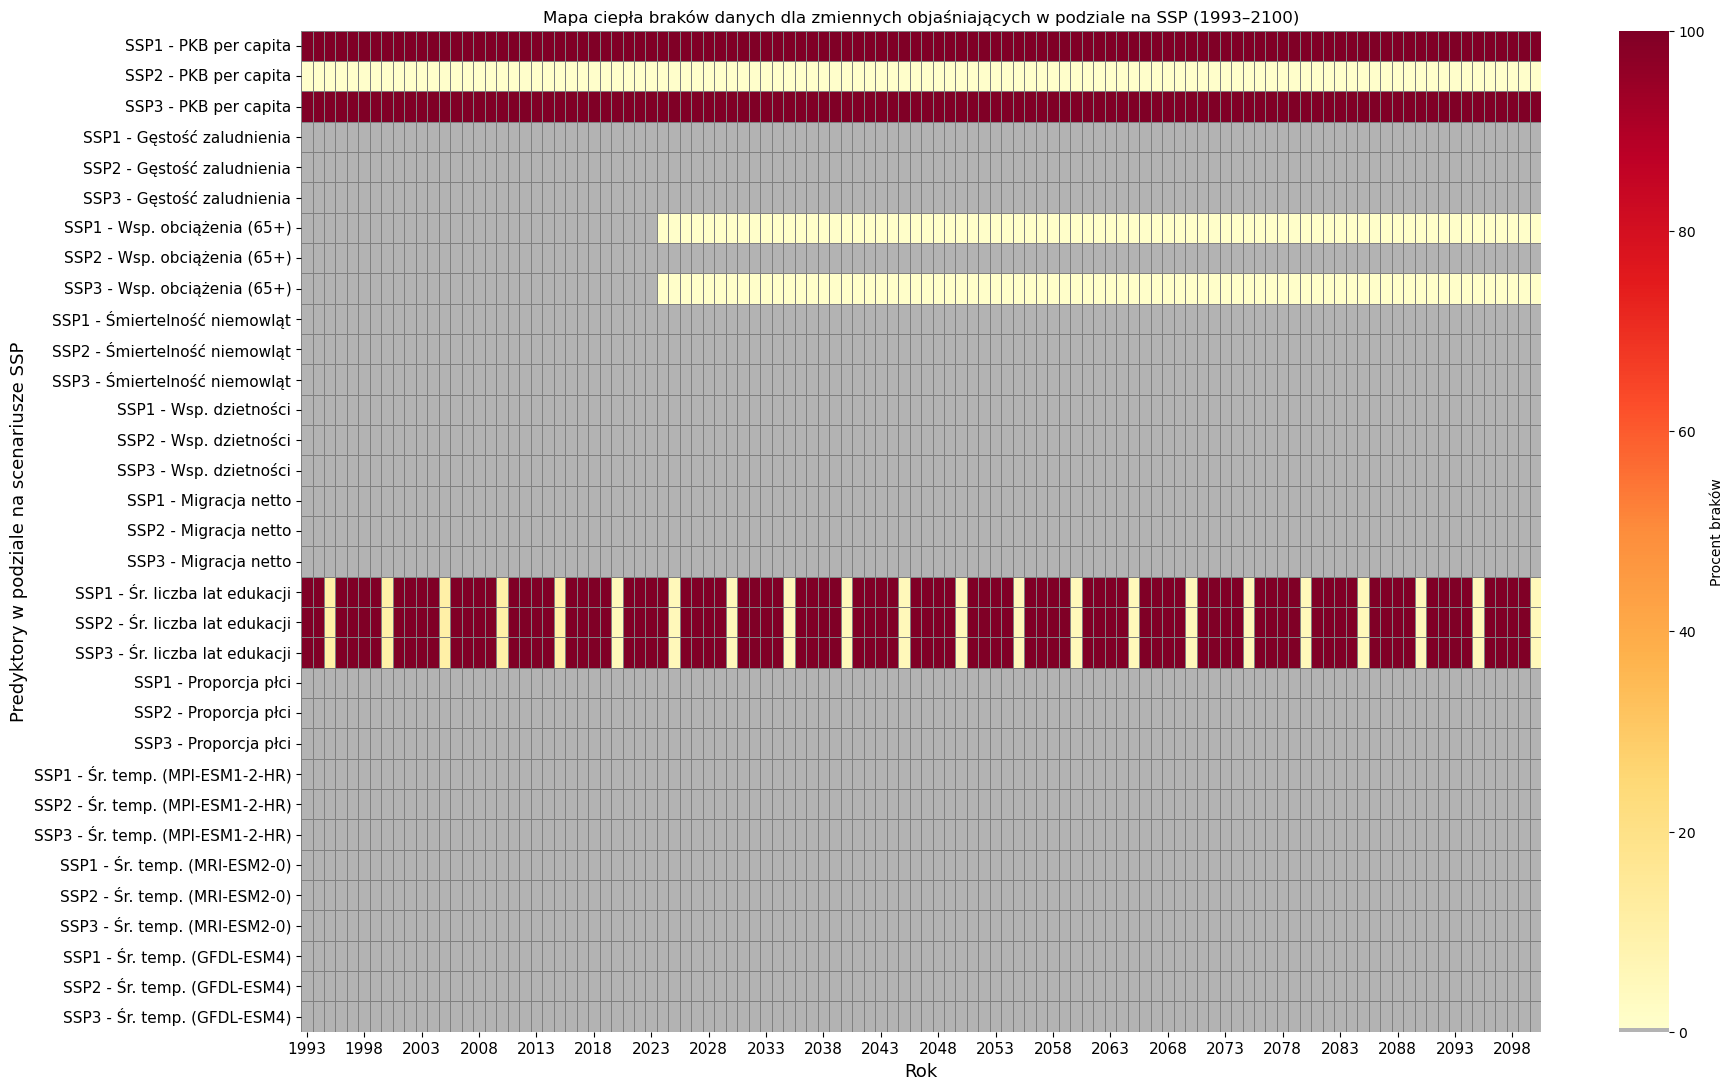

In [74]:
df_names = [
    "gdp_pc1_missing","gdp_pc2_missing","gdp_pc3_missing",
    "p_density1_missing","p_density2_missing","p_density3_missing",
    "old_age1_missing","old_age2_missing","old_age3_missing",
    "imr_value1_missing","imr_value2_missing","imr_value3_missing",
    "fertility_rate1_missing","fertility_rate2_missing","fertility_rate3_missing",
    "net_migration1_missing","net_migration2_missing","net_migration3_missing",
    "mean_school1_missing","mean_school2_missing","mean_school3_missing",
    "sex_ratio1_missing","sex_ratio2_missing","sex_ratio3_missing",
    "mp1_missing","mp2_missing","mp3_missing",
    "mri1_missing","mri2_missing","mri3_missing",
    "gfdl1_missing","gfdl2_missing","gfdl3_missing",
]

label_map = {
    "gdp_pc1_missing": "SSP1 - PKB per capita", "gdp_pc2_missing": "SSP2 - PKB per capita", "gdp_pc3_missing": "SSP3 - PKB per capita",
    "p_density1_missing": "SSP1 - Gęstość zaludnienia", "p_density2_missing": "SSP2 - Gęstość zaludnienia", "p_density3_missing": "SSP3 - Gęstość zaludnienia",
    "old_age1_missing": "SSP1 - Wsp. obciążenia (65+)", "old_age2_missing": "SSP2 - Wsp. obciążenia (65+)", "old_age3_missing": "SSP3 - Wsp. obciążenia (65+)",
    "imr_value1_missing": "SSP1 - Śmiertelność niemowląt", "imr_value2_missing": "SSP2 - Śmiertelność niemowląt", "imr_value3_missing": "SSP3 - Śmiertelność niemowląt",
    "fertility_rate1_missing": "SSP1 - Wsp. dzietności", "fertility_rate2_missing": "SSP2 - Wsp. dzietności", "fertility_rate3_missing": "SSP3 - Wsp. dzietności",
    "net_migration1_missing": "SSP1 - Migracja netto", "net_migration2_missing": "SSP2 - Migracja netto", "net_migration3_missing": "SSP3 - Migracja netto",
    "mean_school1_missing": "SSP1 - Śr. liczba lat edukacji", "mean_school2_missing": "SSP2 - Śr. liczba lat edukacji", "mean_school3_missing": "SSP3 - Śr. liczba lat edukacji",
    "sex_ratio1_missing": "SSP1 - Proporcja płci", "sex_ratio2_missing": "SSP2 - Proporcja płci",  "sex_ratio3_missing": "SSP3 - Proporcja płci",
    "mp1_missing": "SSP1 - Śr. temp. (MPI-ESM1-2-HR)", "mp2_missing": "SSP2 - Śr. temp. (MPI-ESM1-2-HR)", "mp3_missing": "SSP3 - Śr. temp. (MPI-ESM1-2-HR)",
    "mri1_missing": "SSP1 - Śr. temp. (MRI-ESM2-0)", "mri2_missing": "SSP2 - Śr. temp. (MRI-ESM2-0)", "mri3_missing": "SSP3 - Śr. temp. (MRI-ESM2-0)",
    "gfdl1_missing": "SSP1 - Śr. temp. (GFDL-ESM4)", "gfdl2_missing": "SSP2 - Śr. temp. (GFDL-ESM4)", "gfdl3_missing": "SSP3 - Śr. temp. (GFDL-ESM4)"
}

gdp_pc1_missing

def missing_pct_func(df):
    value_col = df.columns[2]
    df = df[(df["year"] >= 1993) & (df["year"] <= 2100)]

    valid = (
        df.dropna(subset=[value_col])
          .drop_duplicates(subset=["country_normalized", "year"])
    )

    present = valid.groupby("year")["country_normalized"].nunique()

    tmp = pd.DataFrame({"year": list(range(1993, 2101))})
    tmp["present"] = tmp["year"].map(present).fillna(0).astype(int)

    tmp["missing_cnt"] = 193 - tmp["present"]
    tmp.loc[tmp["missing_cnt"] < 0, "missing_cnt"] = 0
    tmp["missing_pct"] = tmp["missing_cnt"] / 193 * 100

    return tmp[["year", "missing_pct"]]

frames = []
for nm in df_names:
    df = globals()[nm]
    tmp = missing_pct_func(df)
    tmp["scenario"] = nm
    frames.append(tmp)

all_missing = pd.concat(frames, ignore_index=True)

heat = all_missing.pivot(index="scenario", columns="year", values="missing_pct")
heat = heat.reindex(df_names)
heat.index = heat.index.map(label_map)

base = sns.color_palette("YlOrRd", 256)
base[0] = (0.7, 0.7, 0.7)
cmap = sns.color_palette(base, as_cmap=True)

plt.figure(figsize=(20, 13))
sns.heatmap(
    heat,
    cmap=cmap,
    vmin=0, vmax=100,
    cbar_kws={"label": "Procent braków"},
    xticklabels=5,
    linewidths=0.45,
    linecolor="grey"
)
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)
plt.title('Mapa ciepła braków danych dla zmiennych objaśniających w podziale na SSP (1993–2100)')
plt.xlabel("Rok", fontsize=13)
plt.ylabel("Predyktory w podziale na scenariusze SSP", fontsize=13)

plt.show()